# TFG - Visualización de Resultados

### Estimación de rendimiento de cultivos utilizando inteligencia artificial y datos de observación de la tierra

##### Nacor Olmos Caballero

## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import textwrap

from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("Figuras", exist_ok=True)

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (20, 12),
    "figure.dpi": 150,
    "savefig.dpi": 300,

    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 16,

    "figure.titlesize": 24,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold"
})

## Datos

In [2]:
maiz = pd.read_csv("./CleanData/df_maize_final.csv", index_col=0)
arroz = pd.read_csv("./CleanData/df_rice_final.csv", index_col=0)
trigo = pd.read_csv("./CleanData/df_wheat_final.csv", index_col=0)

# DataFrames para nombres de columnas
col_names_train_maize = pd.read_csv("./CleanData/mod_maiz.csv", index_col=0).columns.tolist()
col_names_train_rice = pd.read_csv("./CleanData/mod_arroz.csv", index_col=0).columns.tolist()
col_names_train_wheat = pd.read_csv("./CleanData/mod_trigo.csv", index_col=0).columns.tolist()

### Resultados de K-Fold

In [3]:
kfold_maiz_rf1 = pd.read_csv("./Resultados/resultados_kfold_maiz_rf1.csv", index_col=0)
kfold_maiz_rf2 = pd.read_csv("./Resultados/resultados_kfold_maiz_rf2.csv", index_col=0)
kfold_maiz_rf3 = pd.read_csv("./Resultados/resultados_kfold_maiz_rf3.csv", index_col=0)
kfold_maiz_xgb1 = pd.read_csv("./Resultados/resultados_kfold_maiz_xgb1.csv", index_col=0)
kfold_maiz_xgb2 = pd.read_csv("./Resultados/resultados_kfold_maiz_xgb2.csv", index_col=0)
kfold_maiz_xgb3 = pd.read_csv("./Resultados/resultados_kfold_maiz_xgb3.csv", index_col=0)
kfold_maiz_lgb1 = pd.read_csv("./Resultados/resultados_kfold_maiz_lgb1.csv", index_col=0)
kfold_maiz_lgb2 = pd.read_csv("./Resultados/resultados_kfold_maiz_lgb2.csv", index_col=0)
kfold_maiz_lgb3 = pd.read_csv("./Resultados/resultados_kfold_maiz_lgb3.csv", index_col=0)
kfold_maiz_svr1 = pd.read_csv("./Resultados/resultados_kfold_maiz_svr1.csv", index_col=0)
kfold_maiz_svr2 = pd.read_csv("./Resultados/resultados_kfold_maiz_svr2.csv", index_col=0)
kfold_maiz_svr3 = pd.read_csv("./Resultados/resultados_kfold_maiz_svr3.csv", index_col=0)

kfold_arroz_rf1 = pd.read_csv("./Resultados/resultados_kfold_arroz_rf1.csv", index_col=0)
kfold_arroz_rf2 = pd.read_csv("./Resultados/resultados_kfold_arroz_rf2.csv", index_col=0)
kfold_arroz_rf3 = pd.read_csv("./Resultados/resultados_kfold_arroz_rf3.csv", index_col=0)
kfold_arroz_xgb1 = pd.read_csv("./Resultados/resultados_kfold_arroz_xgb1.csv", index_col=0)
kfold_arroz_xgb2 = pd.read_csv("./Resultados/resultados_kfold_arroz_xgb2.csv", index_col=0)
kfold_arroz_xgb3 = pd.read_csv("./Resultados/resultados_kfold_arroz_xgb3.csv", index_col=0)
kfold_arroz_lgb1 = pd.read_csv("./Resultados/resultados_kfold_arroz_lgb1.csv", index_col=0)
kfold_arroz_lgb2 = pd.read_csv("./Resultados/resultados_kfold_arroz_lgb2.csv", index_col=0)
kfold_arroz_lgb3 = pd.read_csv("./Resultados/resultados_kfold_arroz_lgb3.csv", index_col=0)
kfold_arroz_svr1 = pd.read_csv("./Resultados/resultados_kfold_arroz_svr1.csv", index_col=0)
kfold_arroz_svr2 = pd.read_csv("./Resultados/resultados_kfold_arroz_svr2.csv", index_col=0)
kfold_arroz_svr3 = pd.read_csv("./Resultados/resultados_kfold_arroz_svr3.csv", index_col=0)

kfold_trigo_rf1 = pd.read_csv("./Resultados/resultados_kfold_trigo_rf1.csv", index_col=0)
kfold_trigo_rf2 = pd.read_csv("./Resultados/resultados_kfold_trigo_rf2.csv", index_col=0)
kfold_trigo_rf3 = pd.read_csv("./Resultados/resultados_kfold_trigo_rf3.csv", index_col=0)
kfold_trigo_xgb1 = pd.read_csv("./Resultados/resultados_kfold_trigo_xgb1.csv", index_col=0)
kfold_trigo_xgb2 = pd.read_csv("./Resultados/resultados_kfold_trigo_xgb2.csv", index_col=0)
kfold_trigo_xgb3 = pd.read_csv("./Resultados/resultados_kfold_trigo_xgb3.csv", index_col=0)
kfold_trigo_lgb1 = pd.read_csv("./Resultados/resultados_kfold_trigo_lgb1.csv", index_col=0)
kfold_trigo_lgb2 = pd.read_csv("./Resultados/resultados_kfold_trigo_lgb2.csv", index_col=0)
kfold_trigo_lgb3 = pd.read_csv("./Resultados/resultados_kfold_trigo_lgb3.csv", index_col=0)
kfold_trigo_svr1 = pd.read_csv("./Resultados/resultados_kfold_trigo_svr1.csv", index_col=0)
kfold_trigo_svr2 = pd.read_csv("./Resultados/resultados_kfold_trigo_svr2.csv", index_col=0)
kfold_trigo_svr3 = pd.read_csv("./Resultados/resultados_kfold_trigo_svr3.csv", index_col=0)

### Resultados de Ventana Temporal

In [4]:
vent_maiz_rf1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_rf1.csv", index_col=0)
vent_maiz_rf2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_rf2.csv", index_col=0)
vent_maiz_rf3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_rf3.csv", index_col=0)
vent_maiz_xgb1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_xgb1.csv", index_col=0)
vent_maiz_xgb2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_xgb2.csv", index_col=0)
vent_maiz_xgb3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_xgb3.csv", index_col=0)
vent_maiz_lgb1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_lgb1.csv", index_col=0)
vent_maiz_lgb2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_lgb2.csv", index_col=0)
vent_maiz_lgb3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_lgb3.csv", index_col=0)
vent_maiz_svr1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_svr1.csv", index_col=0)
vent_maiz_svr2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_svr2.csv", index_col=0)
vent_maiz_svr3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_svr3.csv", index_col=0)

vent_arroz_rf1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_rf1.csv", index_col=0)
vent_arroz_rf2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_rf2.csv", index_col=0)
vent_arroz_rf3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_rf3.csv", index_col=0)
vent_arroz_xgb1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_xgb1.csv", index_col=0)
vent_arroz_xgb2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_xgb2.csv", index_col=0)
vent_arroz_xgb3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_xgb3.csv", index_col=0)
vent_arroz_lgb1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_lgb1.csv", index_col=0)
vent_arroz_lgb2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_lgb2.csv", index_col=0)
vent_arroz_lgb3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_lgb3.csv", index_col=0)
vent_arroz_svr1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_svr1.csv", index_col=0)
vent_arroz_svr2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_svr2.csv", index_col=0)
vent_arroz_svr3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_svr3.csv", index_col=0)

vent_trigo_rf1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_rf1.csv", index_col=0)
vent_trigo_rf2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_rf2.csv", index_col=0)
vent_trigo_rf3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_rf3.csv", index_col=0)
vent_trigo_xgb1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_xgb1.csv", index_col=0)
vent_trigo_xgb2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_xgb2.csv", index_col=0)
vent_trigo_xgb3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_xgb3.csv", index_col=0)
vent_trigo_lgb1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_lgb1.csv", index_col=0)
vent_trigo_lgb2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_lgb2.csv", index_col=0)
vent_trigo_lgb3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_lgb3.csv", index_col=0)
vent_trigo_svr1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_svr1.csv", index_col=0)
vent_trigo_svr2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_svr2.csv", index_col=0)
vent_trigo_svr3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_svr3.csv", index_col=0)

In [5]:
rutas_modelos_kfold = {
    "Random Forests": [kfold_maiz_rf1, kfold_maiz_rf2, kfold_maiz_rf3,
                      kfold_arroz_rf1, kfold_arroz_rf2, kfold_arroz_rf3,
                     kfold_trigo_rf1, kfold_trigo_rf2, kfold_trigo_rf3],
    "XGBoost": [kfold_maiz_xgb1, kfold_maiz_xgb2, kfold_maiz_xgb3,
                kfold_arroz_xgb1, kfold_arroz_xgb2, kfold_arroz_xgb3,
                kfold_trigo_xgb1, kfold_trigo_xgb2, kfold_trigo_xgb3],
    "LightGBM": [kfold_maiz_lgb1, kfold_maiz_lgb2, kfold_maiz_lgb3,
                 kfold_arroz_lgb1, kfold_arroz_lgb2, kfold_arroz_lgb3,
                 kfold_trigo_lgb1, kfold_trigo_lgb2, kfold_trigo_lgb3],
    "SVR": [kfold_maiz_svr1, kfold_maiz_svr2, kfold_maiz_svr3,
            kfold_arroz_svr1, kfold_arroz_svr2, kfold_arroz_svr3,
            kfold_trigo_svr1, kfold_trigo_svr2, kfold_trigo_svr3]
}

rutas_modelos_vent = {
    "Random Forests": [vent_maiz_rf1, vent_maiz_rf2, vent_maiz_rf3,
                      vent_arroz_rf1, vent_arroz_rf2, vent_arroz_rf3,
                      vent_trigo_rf1, vent_trigo_rf2, vent_trigo_rf3],
    "XGBoost": [vent_maiz_xgb1, vent_maiz_xgb2, vent_maiz_xgb3,
                vent_arroz_xgb1, vent_arroz_xgb2, vent_arroz_xgb3,
                vent_trigo_xgb1, vent_trigo_xgb2, vent_trigo_xgb3],
    "LightGBM": [vent_maiz_lgb1, vent_maiz_lgb2, vent_maiz_lgb3,
                 vent_arroz_lgb1, vent_arroz_lgb2, vent_arroz_lgb3,
                 vent_trigo_lgb1, vent_trigo_lgb2, vent_trigo_lgb3],
    "SVR": [vent_maiz_svr1, vent_maiz_svr2, vent_maiz_svr3,
            vent_arroz_svr1, vent_arroz_svr2, vent_arroz_svr3,
            vent_trigo_svr1, vent_trigo_svr2, vent_trigo_svr3]
}

## Visualización

### Comparación de resultados por tipo de modelo, estrategia y metodología

#### Preparación de datos

Vamos a realizar una primera visualización general uniendo los resultados de todos los modelos, así como de las dos estrategias de entrenamiento planteadas y las tres metodologías de agrupamiento aplicadas para cada uno. Emplearemos como métricas el valor medio del rRMSE y rME (rRMSE Global y rME Global, respectivamente).

In [6]:
def unir_resultados(rutas_modelos):
    res = [] 

    for modelo, resultados in rutas_modelos.items():

        for i, df in enumerate(resultados):
            df_aux = df.copy()

            if i < 3:
                cultivo = "Maíz"
            elif i < 6:
                cultivo = "Arroz"
            else:
                cultivo = "Trigo"

            if i in [0, 3, 6]:
                met = 1
            elif i in [1, 4, 7]:
                met = 2
            else:
                met = 3

            res_parciales = {
                "Modelo": modelo,
                "Metodología": met,
                "Cultivo": cultivo,
                "rRMSE Global": df_aux["rRMSE"].mean(),
                "nME Global": df_aux["nME"].mean()
            }

            res.append(res_parciales)
    
    return pd.DataFrame(res)

In [7]:
df_kfold_total = unir_resultados(rutas_modelos_kfold)
df_vent_total = unir_resultados(rutas_modelos_vent)

df_kfold_total["Estrategia"] = "KFold"
df_vent_total["Estrategia"] = "Ventana"

In [8]:
df_total = pd.merge(df_kfold_total, df_vent_total, on=["Modelo", "Metodología", "Cultivo", "Estrategia"], how="outer")

In [9]:
# Combinamos columnas de rRMSE y nME usando combine_first (prioriza KFold y luego Ventana)
df_total["rRMSE"] = df_total["rRMSE Global_x"].combine_first(df_total["rRMSE Global_y"])
df_total["nME"] = df_total["nME Global_x"].combine_first(df_total["nME Global_y"])

# Eliminamos las columnas auxiliares
df_total = df_total.drop(columns=["rRMSE Global_x", "rRMSE Global_y", "nME Global_x", "nME Global_y"])

# Mostramos resultado
df_total.head(10)


,Modelo,Metodología,Cultivo,Estrategia,rRMSE,nME
0,LightGBM,1,Arroz,KFold,8.520371,-0.001882
1,LightGBM,1,Arroz,Ventana,9.603296,0.015390
2,LightGBM,1,Maíz,KFold,19.381190,-0.029543
3,LightGBM,1,Maíz,Ventana,20.171079,-0.011170
4,LightGBM,1,Trigo,KFold,16.211021,-0.024353
5,LightGBM,1,Trigo,Ventana,18.129977,0.028979
6,LightGBM,2,Arroz,KFold,12.933765,-0.002330
7,LightGBM,2,Arroz,Ventana,15.929492,0.004462
8,LightGBM,2,Maíz,KFold,21.409919,-0.027162
9,LightGBM,2,Maíz,Ventana,23.373837,0.028917


#### Gráficos de barras globales

In [10]:
def barplot_global(df_orig):
    """Mostrar un barplot global de rRMSE y nME por modelo.
    
    Args:
        df (DataFrame): DataFrame con los resultados globales por modelo.
    """
    # Agrupamos por modelo para calcular media y desviación estándar
    df = df_orig.copy()
    df = df.groupby(["Modelo"])[["rRMSE", "nME"]].mean().reset_index()
    
    fig, ax = plt.subplots(2, 1, figsize=(22, 14), sharex=False)

    # Paleta de colores
    modelos = df["Modelo"].unique().tolist()
    colores = sns.color_palette("husl", len(modelos))
    paleta = dict(zip(modelos, colores))

    # Barplot de rRMSE
    sns.barplot(data=df.sort_values(by="rRMSE", ascending=True), x="Modelo", y="rRMSE",
                ax=ax[0], label="rRMSE", palette=paleta)
    ax[0].set_title("rRMSE promedio por Modelo", fontsize=22, fontweight="bold")
    ax[0].set_ylabel("rRMSE (%)", fontsize=18, fontweight="bold")
    ax[0].set_xticklabels(ax[0].get_xticklabels())
    ax[0].tick_params(axis="both", labelsize=15)

    # Barplot de nME 
    sns.barplot(data=df.sort_values(by="nME", ascending=True), x="Modelo", y="nME",
                ax=ax[1], label="nME", palette=paleta)
    ax[1].set_title("nME promedio por Modelo", fontsize=22, fontweight="bold")
    ax[1].set_ylabel("nME", fontsize=18, fontweight="bold")
    ax[1].set_xticklabels(ax[1].get_xticklabels())
    ax[1].tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig("Figuras/barplot_global.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/barplot_global.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [11]:
def barplot_comparativo(df_orig):
    """Mostrar un barplot comparativo de rRMSE y nME por cultivo y metodología.
    
    Args:
        df_orig (DataFrame): DataFrame con los resultados por cultivo y metodología.
    """
    df = df_orig.copy()

    # rRMSE
    g1 = sns.catplot(
        data=df,
        x="Modelo",
        y="rRMSE",
        hue="Metodología",
        col="Cultivo",
        kind="bar",
        palette="Set2",
        errorbar="sd",
        height=6,
        aspect=1.4
    )

    g1.set_titles("{col_name}", size=20, weight="bold")

    g1.set_axis_labels("", "rRMSE (%)")

    for ax in g1.axes.flat:
        ax.tick_params(axis="x", labelsize=14, rotation=20)
        ax.tick_params(axis="y", labelsize=14)
        ax.set_xlabel("")
        ax.set_ylabel("rRMSE (%)", fontsize=16, fontweight="bold")

    g1._legend.set_title("Metodología")
    g1._legend.get_title().set_fontsize(16)

    for text in g1._legend.texts:
        text.set_fontsize(14)

    plt.tight_layout()
    plt.savefig("Figuras/barplot_comparativo_rRMSE.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/barplot_comparativo_rRMSE.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # nME
    g2 = sns.catplot(
        data=df,
        x="Modelo",
        y="nME",
        hue="Metodología",
        col="Cultivo",
        kind="bar",
        palette="Set2",
        errorbar="sd",
        height=6,
        aspect=1.4
    )

    g2.set_titles("{col_name}", size=20, weight="bold")

    g2.set_axis_labels("", "nME")

    for ax in g2.axes.flat:
        ax.tick_params(axis="x", labelsize=14, rotation=20)
        ax.tick_params(axis="y", labelsize=14)
        ax.set_xlabel("")
        ax.set_ylabel("nME", fontsize=16, fontweight="bold")

    g2._legend.set_title("Metodología")
    g2._legend.get_title().set_fontsize(16)

    for text in g2._legend.texts:
        text.set_fontsize(14)

    plt.tight_layout()
    plt.savefig("Figuras/barplot_comparativo_nME.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/barplot_comparativo_nME.pdf", format="pdf", bbox_inches="tight")
    plt.show()

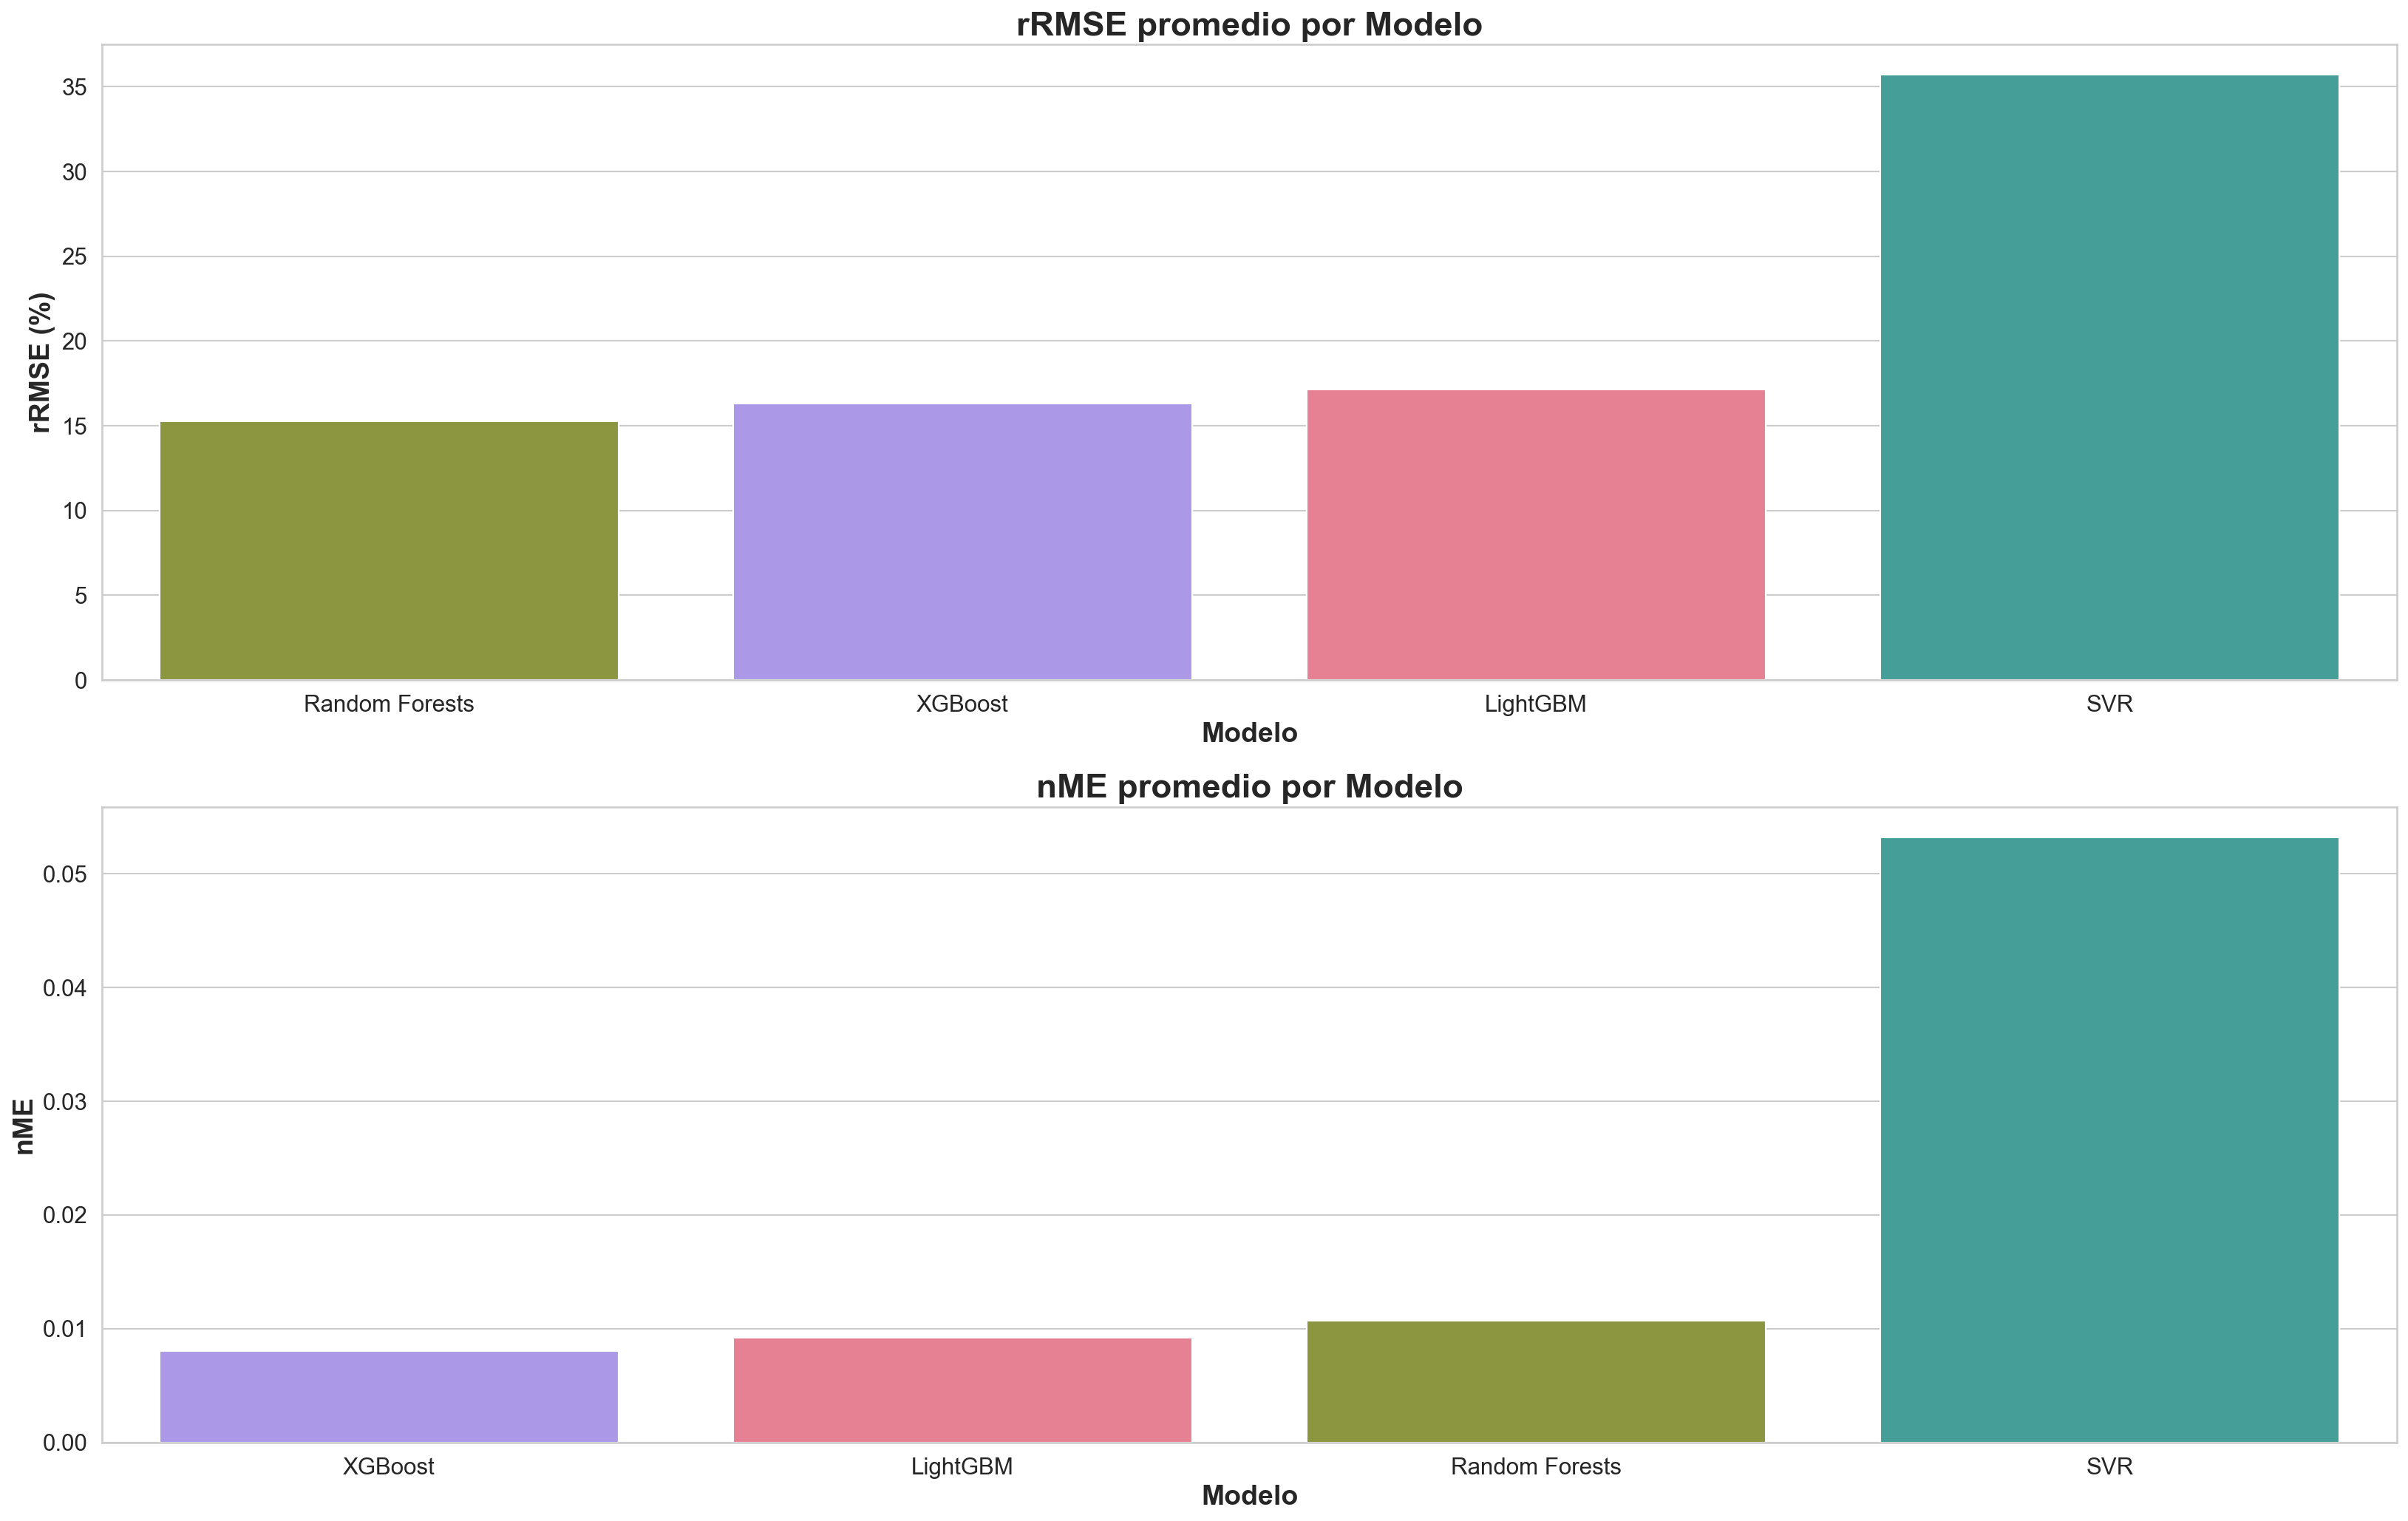

In [12]:
barplot_global(df_total)

De manera general, podemos deicr que los modelos SVR son los que peor funcionan para nuestro caso de estudio.

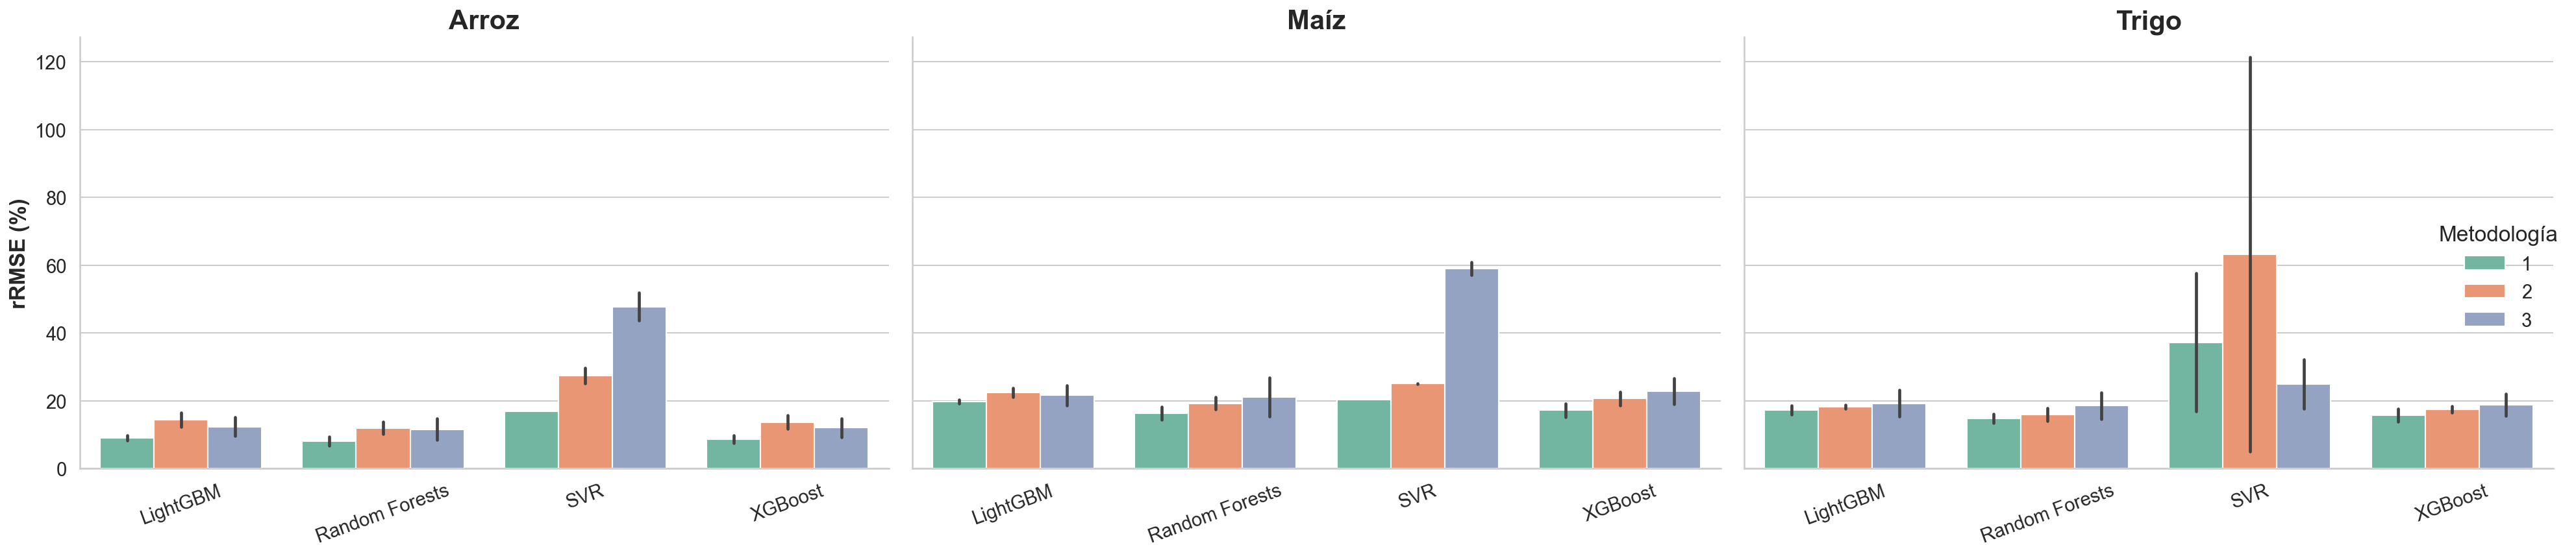

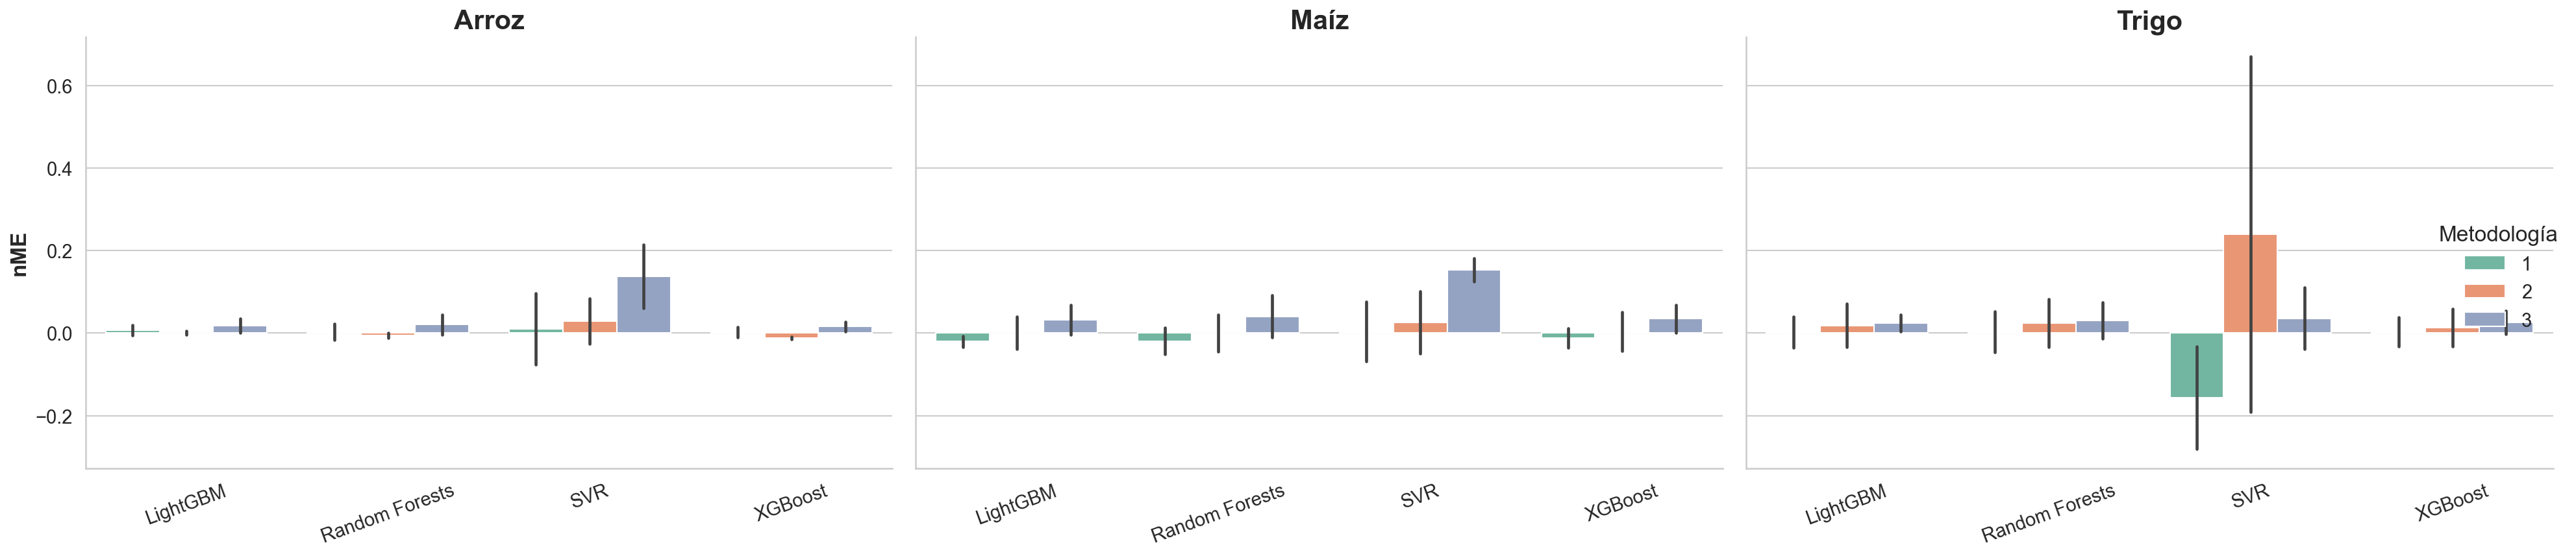

In [13]:
barplot_comparativo(df_total)

Aquí ya podemos observar algo más de información acerca del comportamiento de los modelos en cuanto al tipo de metodología y cultivo.

#### Boxplots globales

In [14]:
def boxplot_global(df_orig):
    """Mostrar un boxplot global de rRMSE y nME por modelo.
    
    Args:
        df (DataFrame): DataFrame con los resultados globales.
    """
    df = df_orig.copy()
    df = df.groupby("Modelo")[["rRMSE", "nME"]].mean().reset_index()

    orden_rrmse = df.sort_values(by="rRMSE")["Modelo"].tolist()
    orden_me = df.sort_values(by="nME")["Modelo"].tolist()

    fig, ax = plt.subplots(2, 1, figsize=(22, 14), sharex=False)

    # Paleta de colores
    modelos = df["Modelo"].unique().tolist()
    colores = sns.color_palette("husl", len(modelos))
    paleta = dict(zip(modelos, colores))

    # Boxplot de rRMSE
    sns.boxplot(data=df_orig, x="Modelo", y="rRMSE",
                ax=ax[0], palette=paleta, order=orden_rrmse)
    ax[0].set_ylabel("rRMSE (%)", fontsize=18, fontweight="bold")
    ax[0].set_xticklabels(ax[0].get_xticklabels())
    ax[0].tick_params(axis="both", labelsize=15)

    # Boxplot de nME 
    sns.boxplot(data=df_orig, x="Modelo", y="nME",
                ax=ax[1], palette=paleta, order=orden_me)
    ax[1].set_ylabel("nME")
    ax[1].set_xticklabels(ax[1].get_xticklabels())
    ax[1].tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig("Figuras/boxplot_global.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/boxplot_global.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    print("Valores numéricos de rRMSE (%) y nME por Modelo:\n", df[["Modelo", "rRMSE", "nME"]].to_string(index=False))

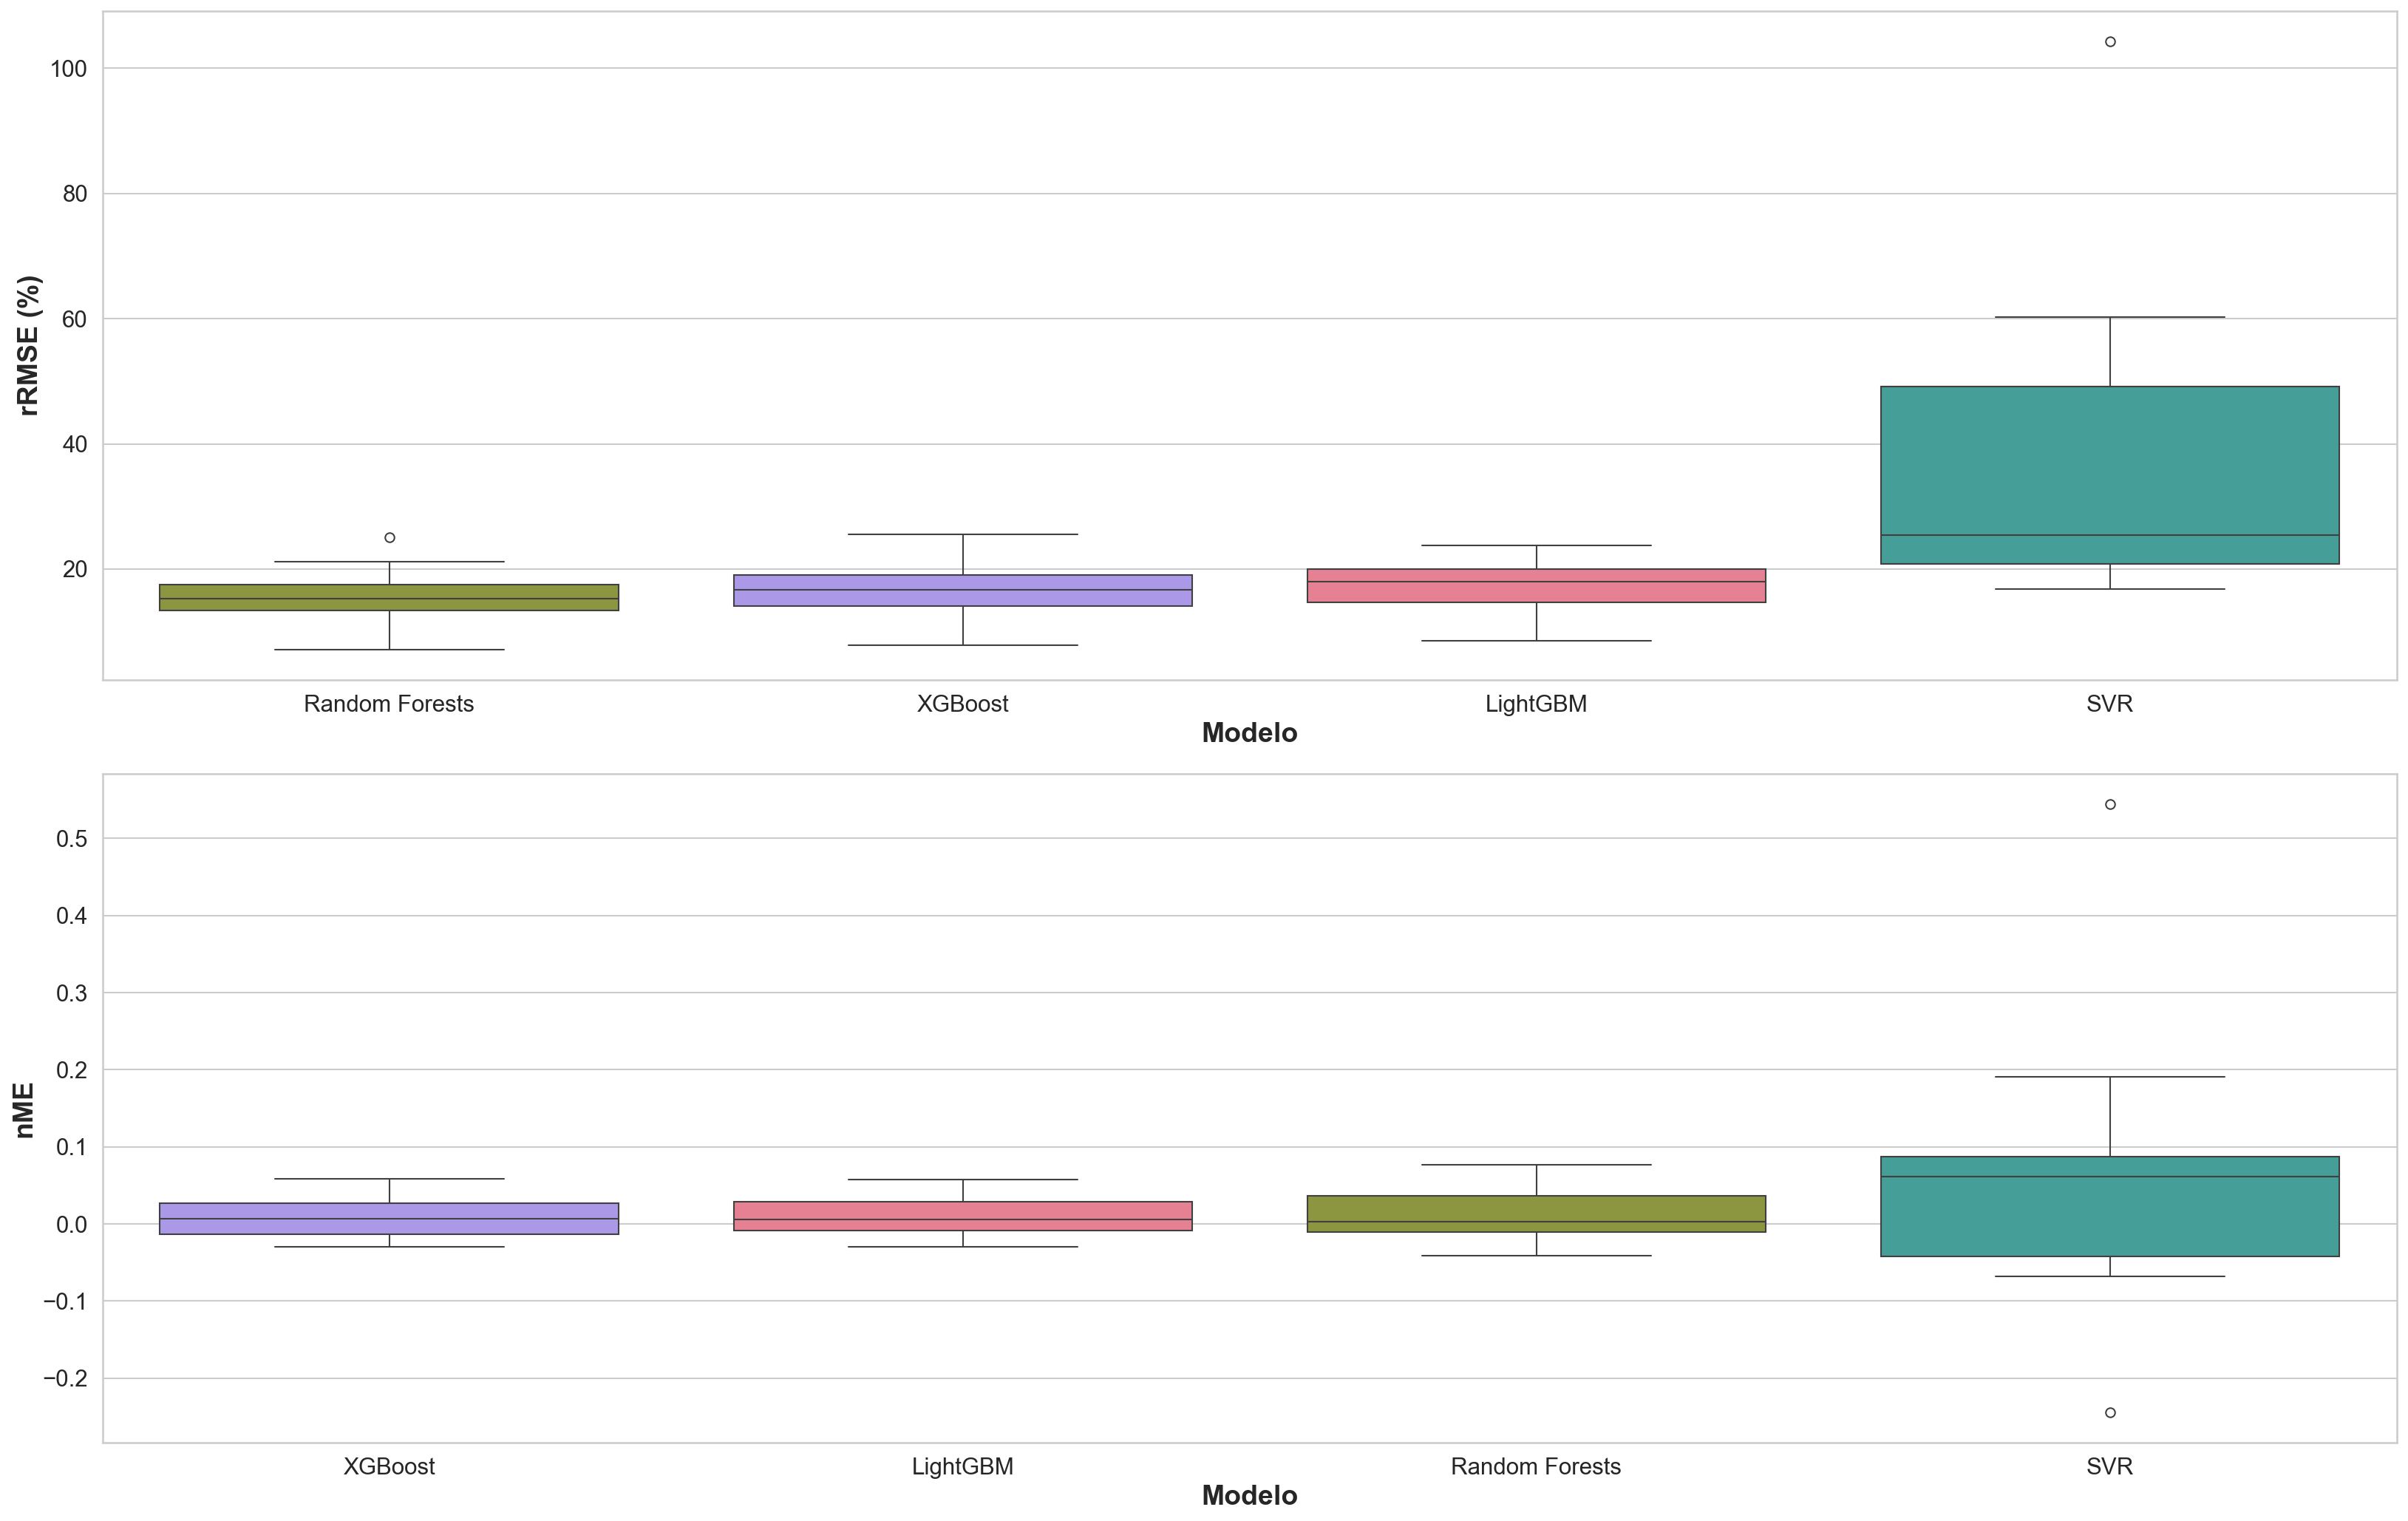

Valores numéricos de rRMSE (%) y nME por Modelo:
         Modelo     rRMSE      nME
      LightGBM 17.134362 0.009226
Random Forests 15.278199 0.010696
           SVR 35.717885 0.053214
       XGBoost 16.331330 0.008077


In [15]:
boxplot_global(df_total)

In [16]:
def boxplot_comparativo(df_orig):
    """Mostrar un barplot comparativo de rRMSE y nME por cultivo y metodología.
    
    Args:
        df_orig (DataFrame): DataFrame con los resultados por cultivo y metodología.
    """
    df = df_orig.copy()

    # rRMSE
    g1 = sns.catplot(
        data=df,
        x="Modelo",
        y="rRMSE",
        col="Cultivo",
        kind="box",
        palette="Set2",
        height=6,
        aspect=1.4
    )

    g1.set_titles("{col_name}", size=20, weight="bold")
    g1.set_axis_labels("", "rRMSE (%)")

    for ax in g1.axes.flat:
        ax.tick_params(axis="x", labelsize=14, rotation=20)
        ax.tick_params(axis="y", labelsize=14)

        ax.set_xlabel("")
        ax.set_ylabel("rRMSE (%)", fontsize=16, fontweight="bold")

    g1.fig.suptitle(
        "Distribución de rRMSE por Modelo y Cultivo",
        fontsize=24,
        fontweight="bold"
    )

    g1.fig.subplots_adjust(top=0.82)

    g1.savefig(
        "Figuras/boxplot_rrmse_comparativo.svg",
        format="svg",
        bbox_inches="tight"
    )

    g1.savefig(
        "Figuras/boxplot_rrmse_comparativo.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    plt.savefig("Figuras/boxplot_comparativo_rRMSE.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/boxplot_comparativo_rRMSE.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # nME
    g2 = sns.catplot(
        data=df,
        x="Modelo",
        y="nME",
        col="Cultivo",
        kind="box",
        palette="Set2",
        height=6,
        aspect=1.4
    )

    g2.set_titles("{col_name}", size=20, weight="bold")

    g2.set_axis_labels("", "nME")

    for ax in g2.axes.flat:
        ax.tick_params(axis="x", labelsize=14, rotation=20)
        ax.tick_params(axis="y", labelsize=14)

        ax.set_xlabel("")
        ax.set_ylabel("nME", fontsize=16, fontweight="bold")

    g2.fig.suptitle(
        "Distribución de nME por Modelo y Cultivo",
        fontsize=24,
        fontweight="bold"
    )

    g2.fig.subplots_adjust(top=0.82)

    g2.savefig(
        "Figuras/boxplot_nme_comparativo.svg",
        format="svg",
        bbox_inches="tight"
    )

    g2.savefig(
        "Figuras/boxplot_nme_comparativo.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    plt.savefig("Figuras/boxplot_comparativo_nME.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/boxplot_comparativo_nME.pdf", format="pdf", bbox_inches="tight")
    plt.show()

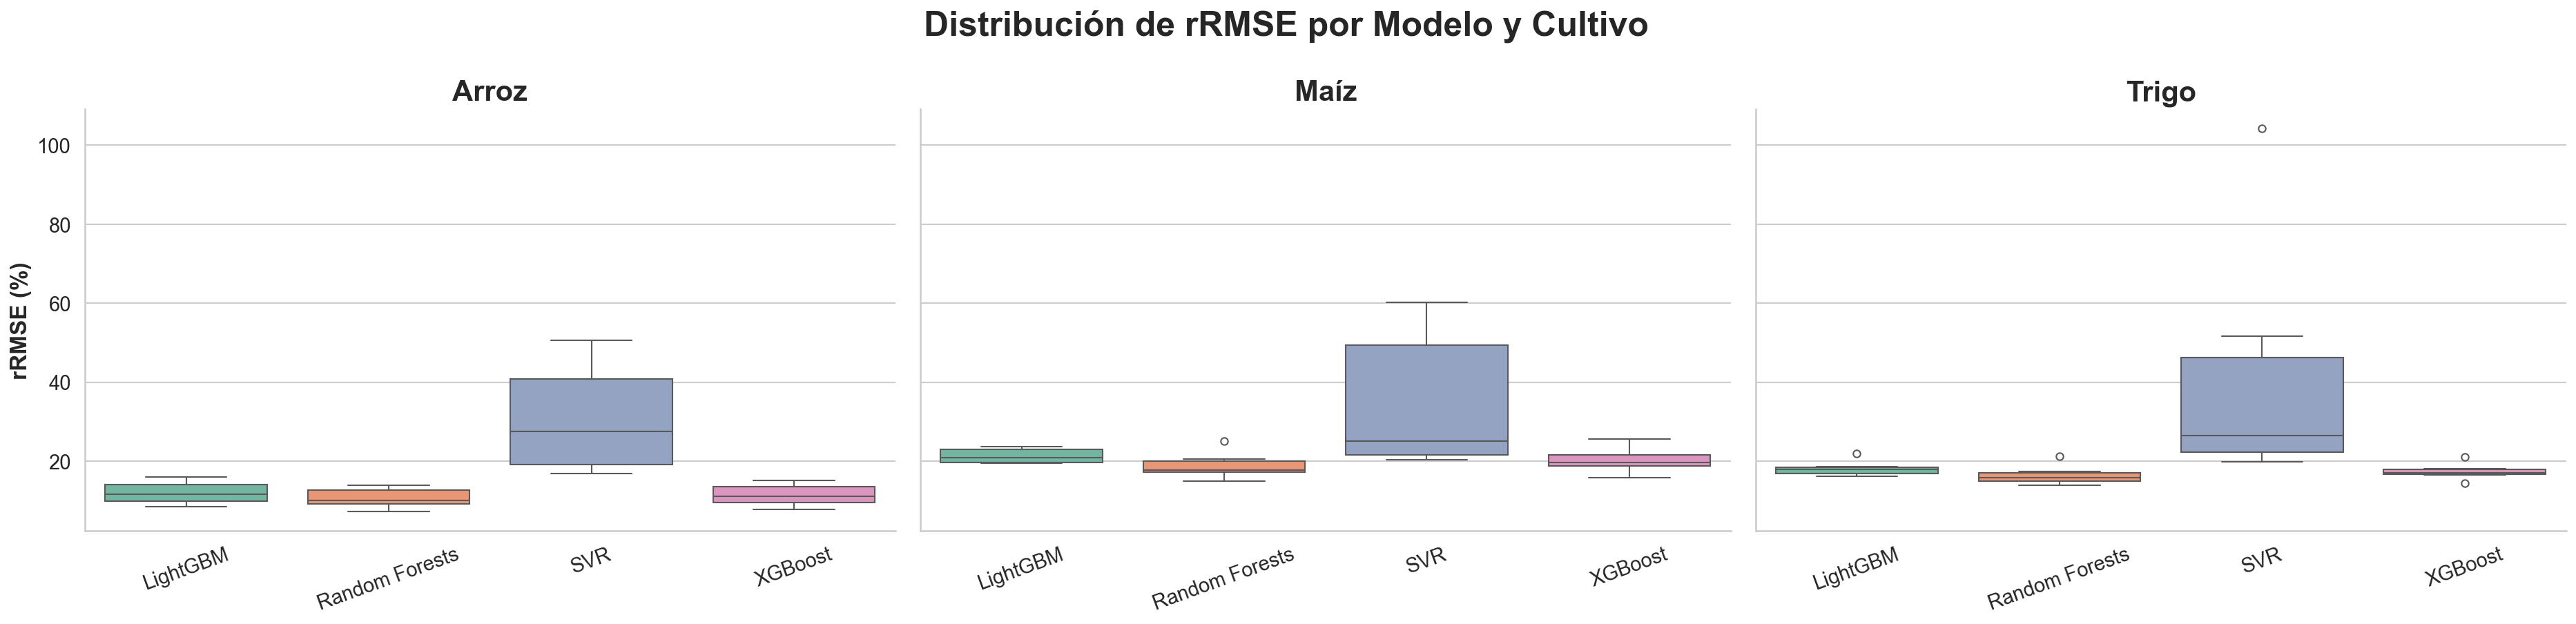

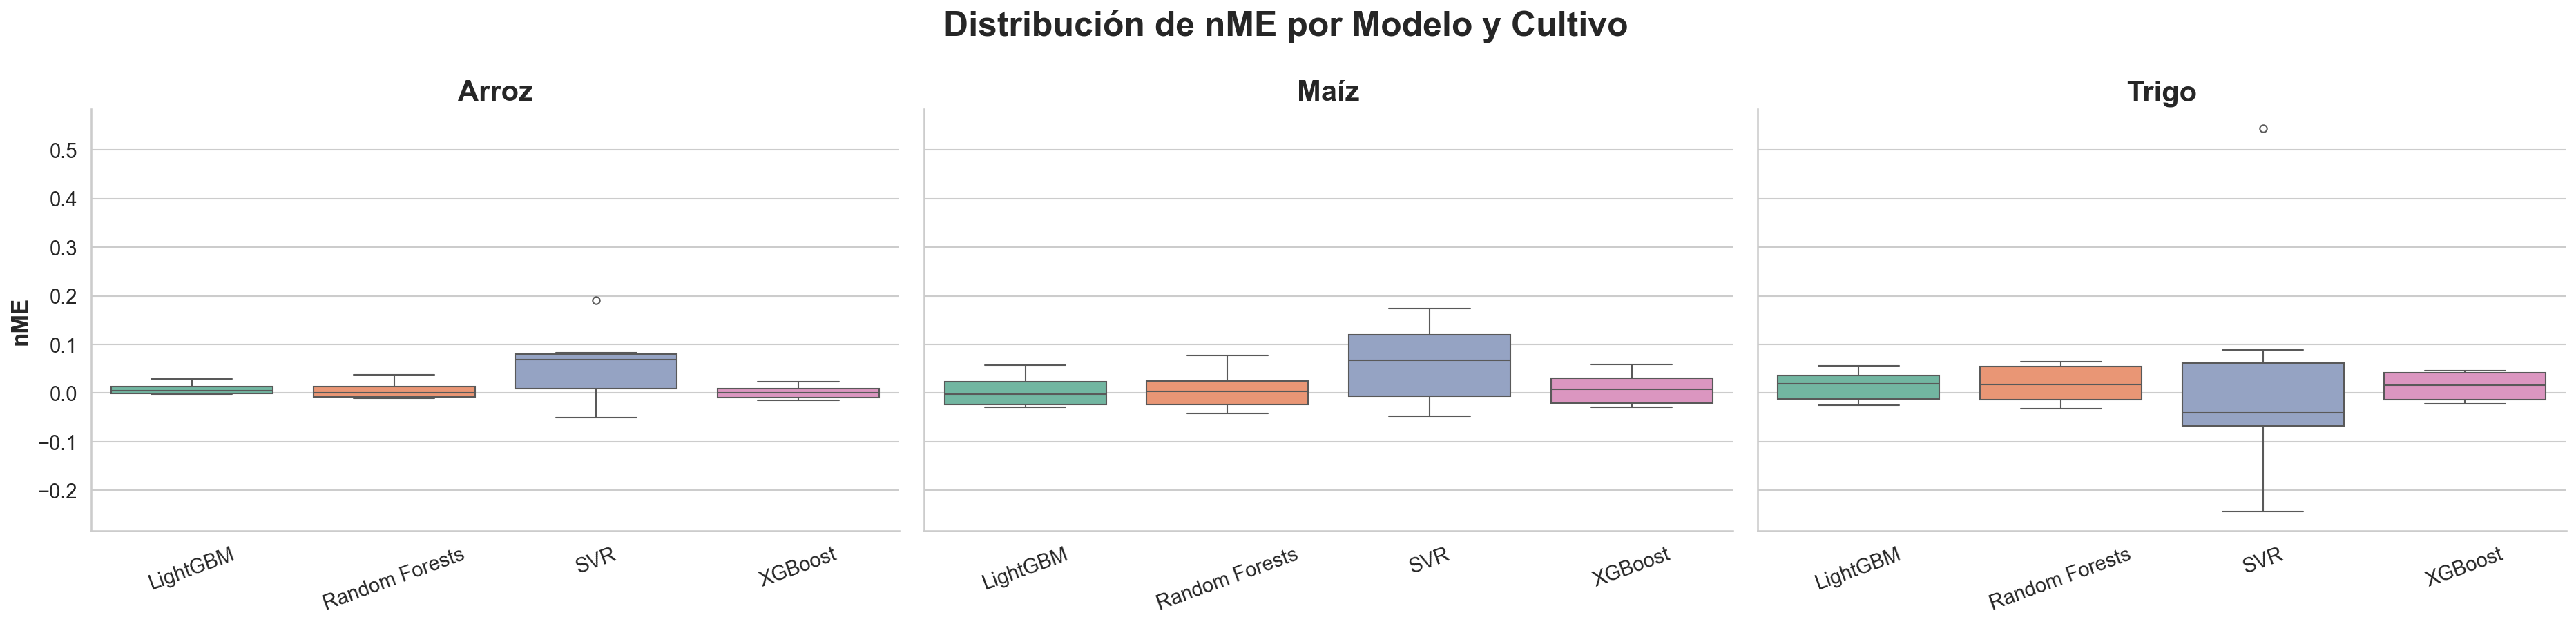

In [17]:
boxplot_comparativo(df_total)

#### Conclusiones

Con los resultados anteriores observamos que Random Forest es el mejor modelo en cuanto al error cuadrático relativo (rRMSE), aunque presenta outliers, seguido de XGBoost. En cuanto al error medio absoluto, vemos que el modelo con menor promedio es XGBoost, seguido de LightGBM y Random Forest.

Podríamos decir a simple vista que el modelo que mejor funciona en general es XGBoost, sin embargo, si tenemos en cuenta los valores numéricos vemos que los resultados de LightGBM no distan en gran medida de los de XGBoost y, además, observamos menor dispersión en los boxplots de LightGBM.

### Comparación de resultados por tipo de cultivo

#### Heatmap comparativo de rRMSE por modelo, estrategia y metodología, para cada cultivo.

In [18]:
def heatmap_comparacion(df_orig, metric):

    fig, axes = plt.subplots(1, 3, figsize=(38, 14), sharey=True)

    
    vmin = df_orig[metric].min()
    vmax = df_orig[metric].max()

    for i, cultivo in enumerate(df_orig['Cultivo'].unique()):
        df_cultivo = df_orig[df_orig['Cultivo'] == cultivo]
        pivot = df_cultivo.pivot_table(
            index='Modelo', columns=['Estrategia', 'Metodología'], values=metric)
        
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=0.5,
            ax=axes[i],
            annot_kws={"size": 18, "weight": "bold"},
            vmin=vmin,
            vmax=vmax,
        )

        axes[i].set_title(f"{metric}(%) - {cultivo}",
            fontsize=22,
            fontweight="bold")
        
        axes[i].set_xlabel("Estrategia - Metodología",
            fontsize=22,
            fontweight="bold")
        
        if i == 0:
            axes[i].set_ylabel(
                "Modelo",
                fontsize=22,
                fontweight="bold"
            )

            axes[i].tick_params(
                axis="y",
                labelsize=22
            )

        else:
            axes[i].set_ylabel("")

            axes[i].tick_params(
                axis="y",
                left=False,
                labelleft=False
            )
                
        axes[i].tick_params(
            axis="x",
            labelsize=22,
            rotation=45)

            
    plt.tight_layout()
    plt.savefig("Figuras/heatmap_comparativo_rRMSE.svg", format="svg", bbox_inches="tight")
    plt.savefig("Figuras/heatmap_comparativo_rRMSE.pdf", format="pdf", bbox_inches="tight")
    plt.show()
        

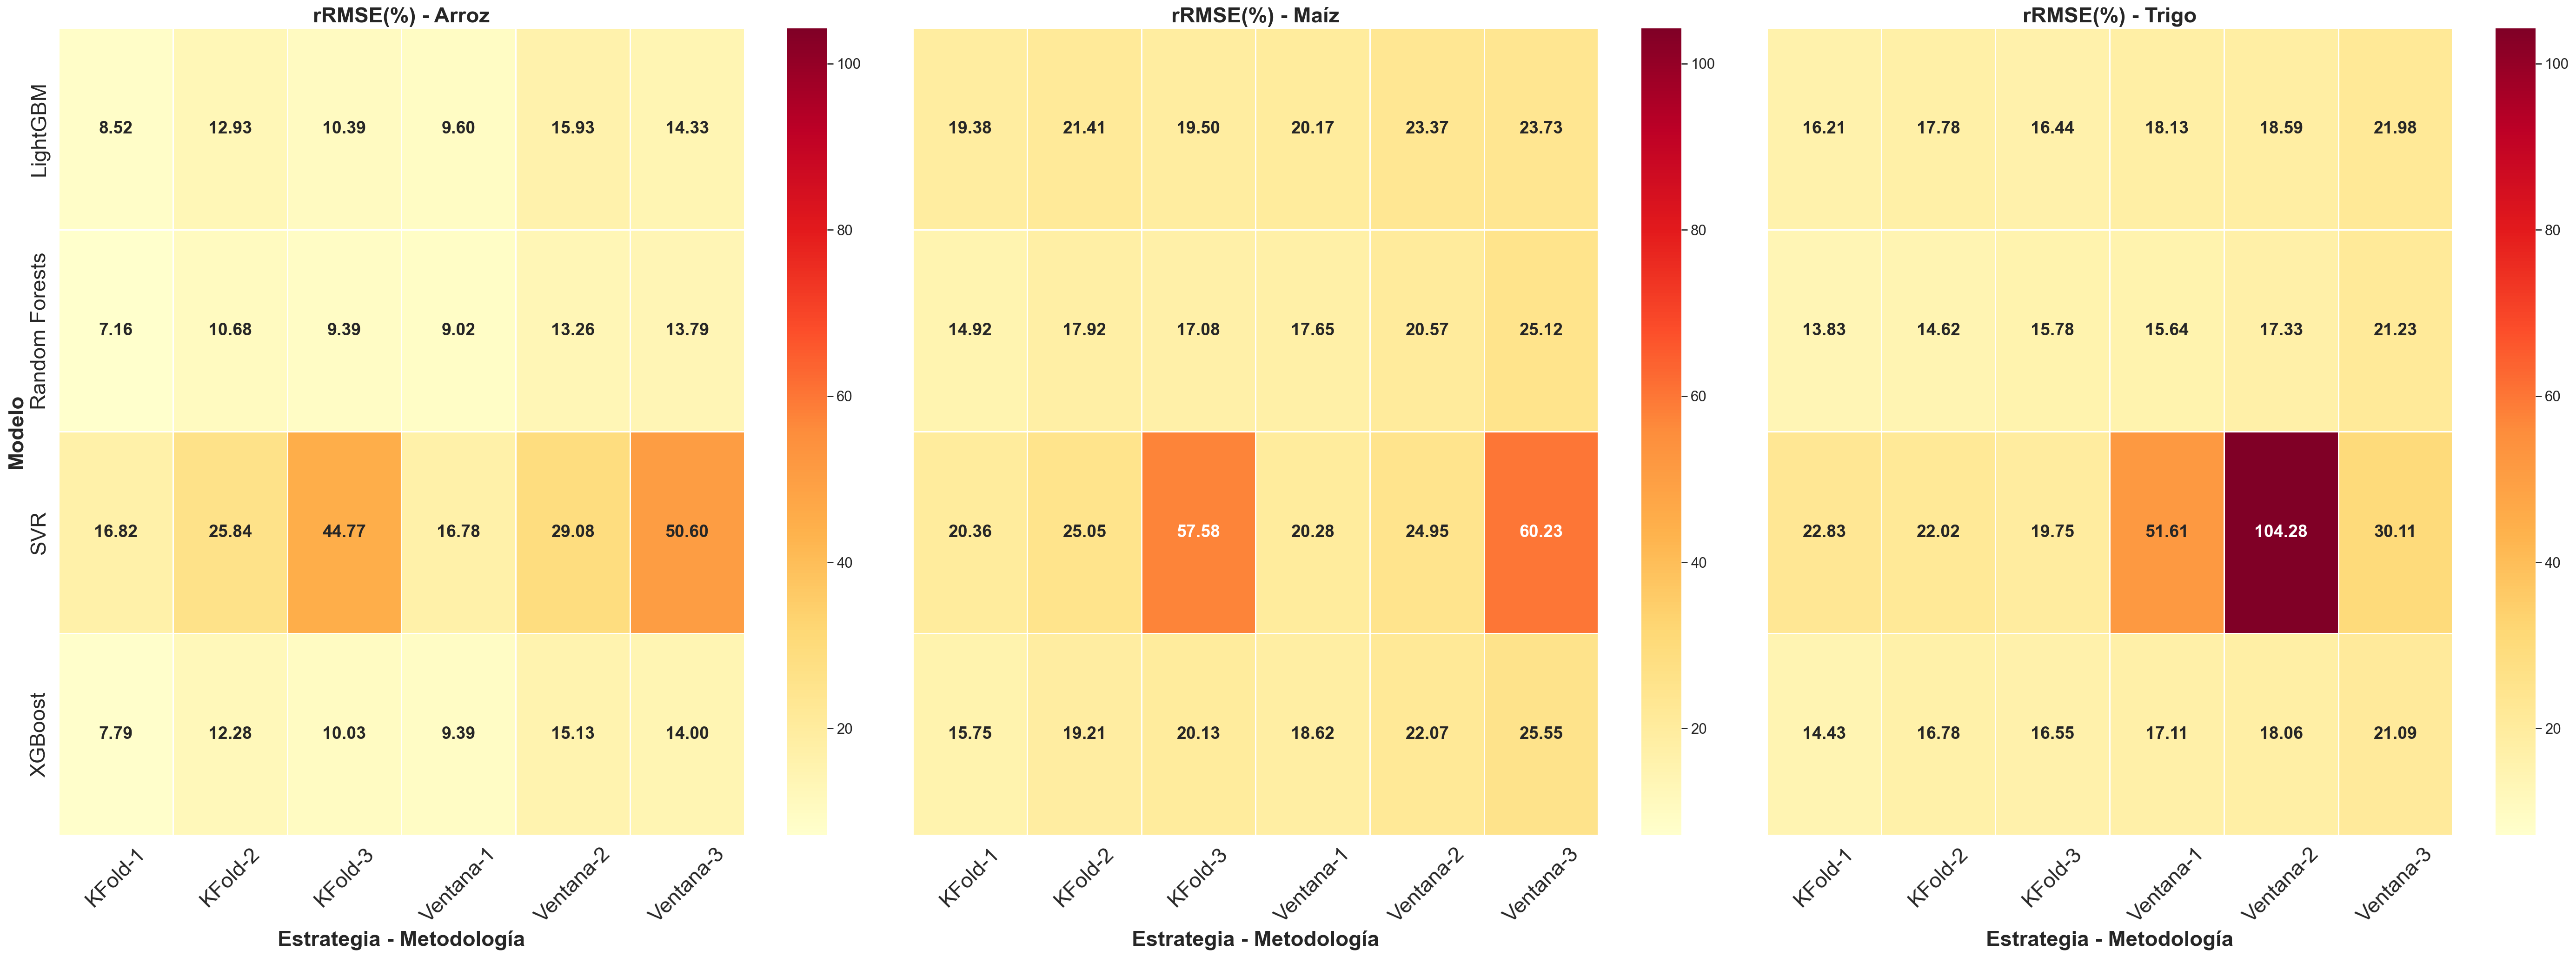

In [19]:
heatmap_comparacion(df_total, 'rRMSE')

##### Top 3 modelos por cultivo

· Arroz -> kfold_arroz_rf1 (7.16%), kfold_arroz_xgb1 (7.79%) & kfold_arroz_lgb1 (8.52%)

· Maiz -> kfold_maiz_rf1 (14.92%), kfold_maiz_xgb1 (15.75%) & kfold_maiz_rf3 (17.08%)

· Trigo -> kfold_trigo_rf1 (13.83%), kfold_trigo_xgb1 (14.43%) & kfold_trigo_rf2 (14.62%)

##### Mejores modelos por cultivo y tipo de modelo

· Arroz -> kfold_arroz_lgb1 (8.52%), kfold_arroz_rf1 (7.16%), vent_arroz_svr1 (16.78%) & kfold_arroz_xgb1 (7.79%)

· Maiz -> kfold_maiz_lgb1 (19.38%), kfold_maiz_rf1 (14.92%), vent_maiz_svr1 (20.28%), & kfold_maiz_xgb1 (15.75%)

· Trigo -> kfold_trigo_lgb1 (16.21%), kfold_trigo_rf1 (13.83%), kfold_trigo_svr3 (19.75%) & kfold_trigo_xgb1 (14.43%)


In [20]:
def crear_tabla_top3_config(df_total, top_n=3, guardar=True):
    """
    Crea una tabla con las mejores configuraciones por cultivo
    según menor rRMSE.
    """

    df = df_total.copy()

    # Ordenar por cultivo y rRMSE
    df_tabla = (
        df.sort_values(["Cultivo", "rRMSE"], ascending=[True, True])
          .groupby("Cultivo")
          .head(top_n)
          .reset_index(drop=True)
    )

    # Ranking
    df_tabla["Ranking"] = (
        df_tabla.groupby("Cultivo").cumcount() + 1
    )

    # Selección de columnas
    df_tabla = df_tabla[
        ["Cultivo", "Ranking", "Modelo",
         "Estrategia", "Metodología", "rRMSE"]
    ]

    # Redondeo
    df_tabla["rRMSE"] = df_tabla["rRMSE"].round(2)

    # Renombrar columna
    df_tabla = df_tabla.rename(
        columns={"rRMSE": "rRMSE (%)"}
    )

    df_tabla = df_tabla.reset_index(drop=True)
    idx_mejores = df_tabla.groupby("Cultivo")["rRMSE (%)"].idxmin()

    # Crear figura
    fig, ax = plt.subplots(figsize=(15, 3))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_tabla.values,
        colLabels=df_tabla.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    # Columna rRMSE
    col_rrmse = list(df_tabla.columns).index("rRMSE (%)")

    # Negrita en mejores resultados
    for idx in idx_mejores:
        fila_tabla = idx + 1
        tabla[(fila_tabla, col_rrmse)].set_text_props(weight="bold")

    # Estilo
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(12)
    tabla.scale(1.2, 1.8)

    for (row, col), cell in tabla.get_celld().items():

        # Cabecera
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#40466e")

        # Filas alternas
        else:
            cell.set_facecolor("#f5f5f5" if row % 2 == 0 else "white")

    plt.tight_layout()

    # Guardado
    if guardar:
        plt.savefig(
            "Figuras/tabla_top3_config.svg",
            format="svg",
            bbox_inches="tight"
        )

        plt.savefig(
            "Figuras/tabla_top3_config.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()

    return df_tabla

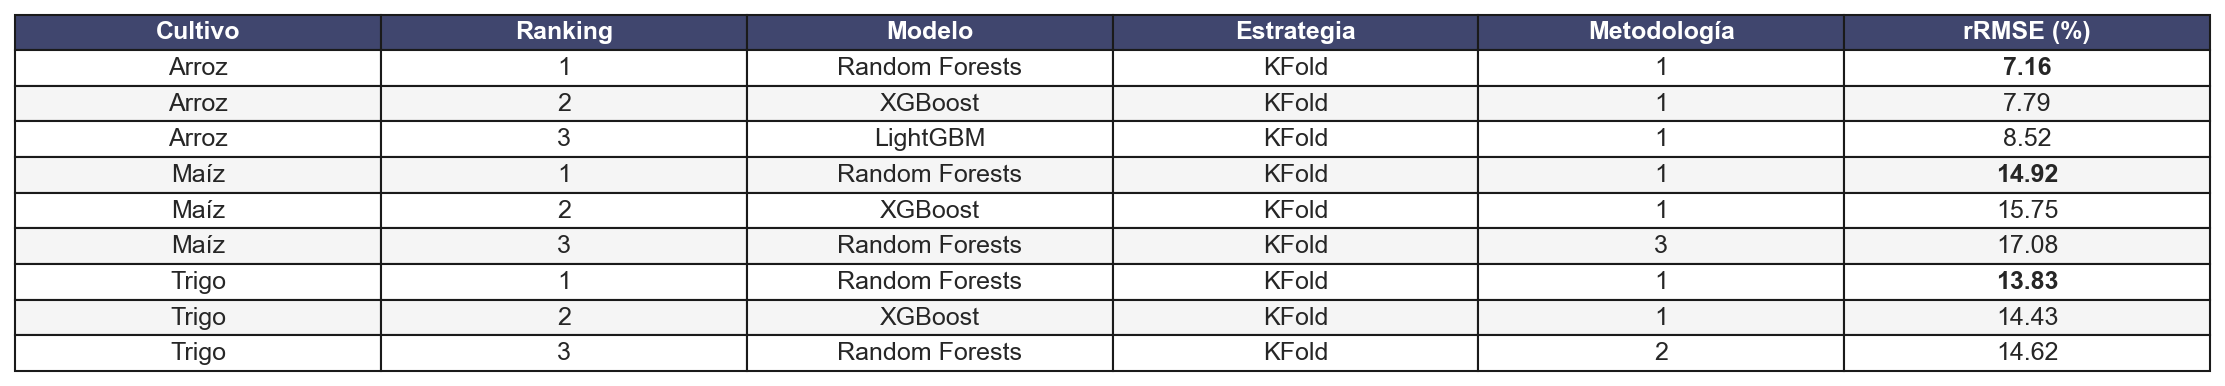

,Cultivo,Ranking,Modelo,Estrategia,Metodología,rRMSE (%)
0,Arroz,1,Random Forests,KFold,1,7.16
1,Arroz,2,XGBoost,KFold,1,7.79
2,Arroz,3,LightGBM,KFold,1,8.52
3,Maíz,1,Random Forests,KFold,1,14.92
4,Maíz,2,XGBoost,KFold,1,15.75
5,Maíz,3,Random Forests,KFold,3,17.08
6,Trigo,1,Random Forests,KFold,1,13.83
7,Trigo,2,XGBoost,KFold,1,14.43
8,Trigo,3,Random Forests,KFold,2,14.62


In [21]:
tabla_top3 = crear_tabla_top3_config(df_total, top_n=3)
tabla_top3

In [22]:
def crear_tabla_por_modelo(df_total, guardar=True):
    """
    Crea una tabla con la mejor configuración por cultivo y tipo de modelo,
    seleccionando el menor rRMSE de cada combinación Cultivo-Modelo.
    """

    df = df_total.copy()

    # Seleccionar mejor configuración por Cultivo y Modelo
    idx_mejores = df.groupby(["Cultivo", "Modelo"])["rRMSE"].idxmin()
    df_tabla = df.loc[idx_mejores].copy()

    # Ordenar tabla
    orden_cultivos = ["Maíz", "Arroz", "Trigo"]
    df_tabla["Cultivo"] = pd.Categorical(
        df_tabla["Cultivo"],
        categories=orden_cultivos,
        ordered=True
    )

    df_tabla = df_tabla.sort_values(
        ["Cultivo", "rRMSE"],
        ascending=[True, True]
    )

    # Selección de columnas
    df_tabla = df_tabla[
        ["Cultivo", "Modelo", "Estrategia", "Metodología", "rRMSE"]
    ]

    # Redondeo y renombrado
    df_tabla["rRMSE"] = df_tabla["rRMSE"].round(2)
    df_tabla = df_tabla.rename(columns={"rRMSE": "rRMSE (%)"})

    df_tabla = df_tabla.reset_index(drop=True)
    idx_mejores = df_tabla.groupby("Cultivo")["rRMSE (%)"].idxmin()

    # Crear figura
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_tabla.values,
        colLabels=df_tabla.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    # Columna rRMSE
    col_rrmse = list(df_tabla.columns).index("rRMSE (%)")

    # Negrita en mejores resultados
    for idx in idx_mejores:
        fila_tabla = idx + 1
        tabla[(fila_tabla, col_rrmse)].set_text_props(weight="bold")

    # Estilo
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(12)
    tabla.scale(1.2, 1.8)

    for (row, col), cell in tabla.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#40466e")
        else:
            cell.set_facecolor("#f5f5f5" if row % 2 == 0 else "white")


    plt.tight_layout()

    if guardar:
        plt.savefig(
            "Figuras/tabla_top_cult_model.svg",
            format="svg",
            bbox_inches="tight"
        )

        plt.savefig(
            "Figuras/tabla_top_cult_model.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()

    return df_tabla

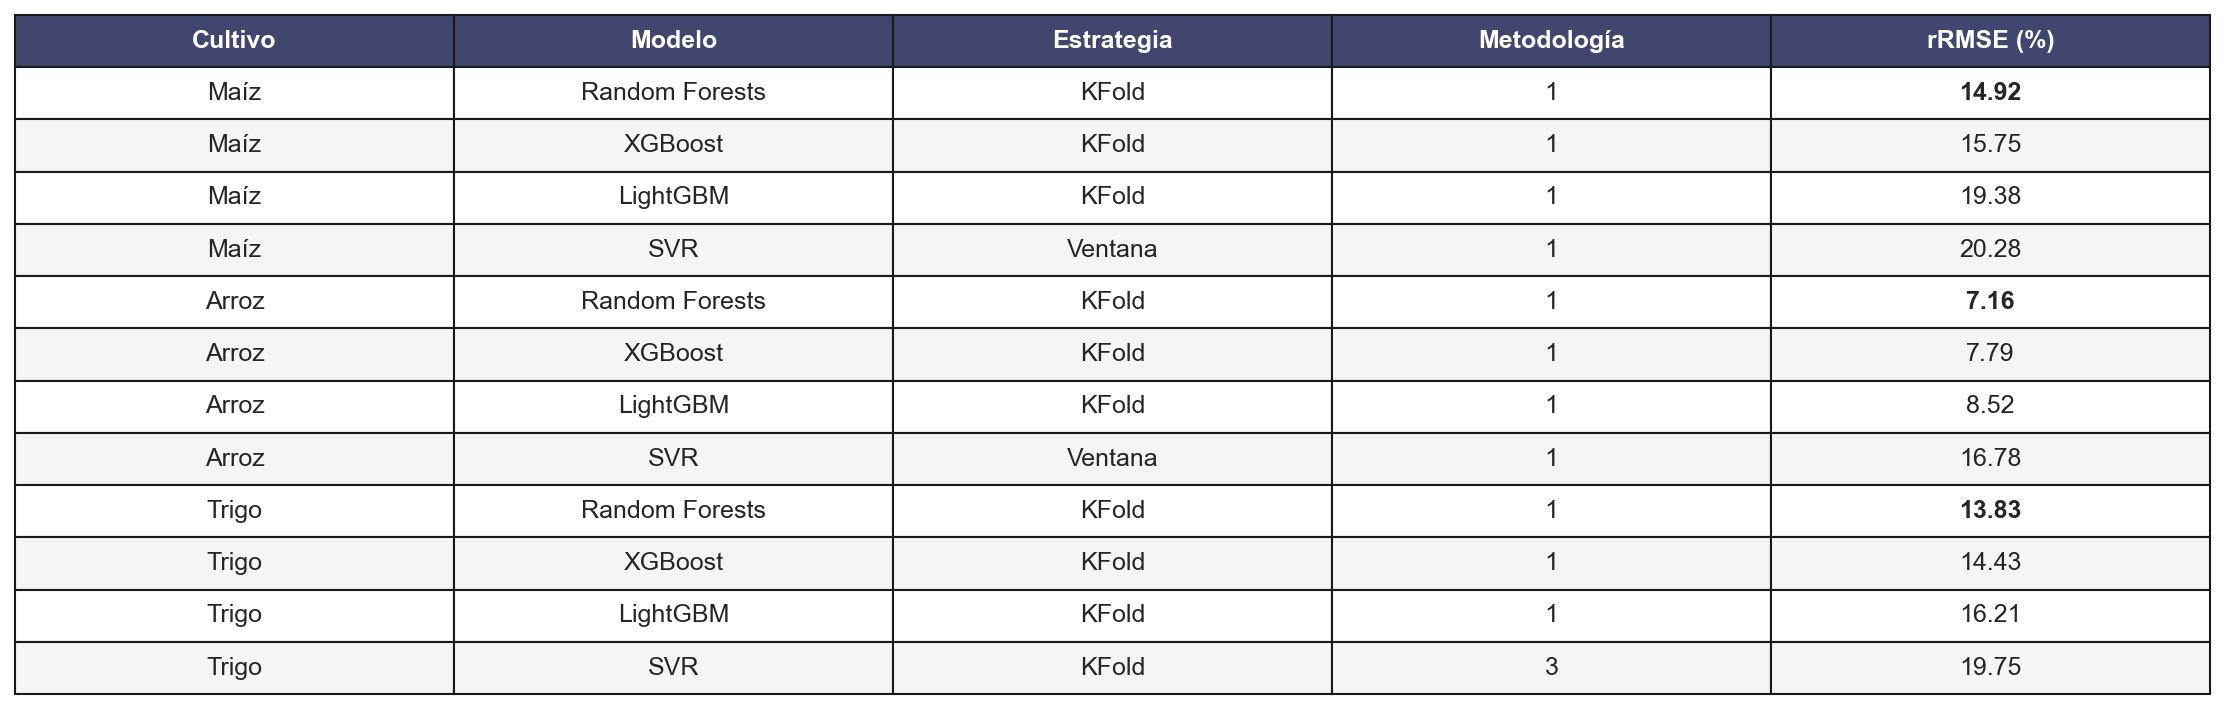

,Cultivo,Modelo,Estrategia,Metodología,rRMSE (%)
0,Maíz,Random Forests,KFold,1,14.92
1,Maíz,XGBoost,KFold,1,15.75
2,Maíz,LightGBM,KFold,1,19.38
3,Maíz,SVR,Ventana,1,20.28
4,Arroz,Random Forests,KFold,1,7.16
5,Arroz,XGBoost,KFold,1,7.79
6,Arroz,LightGBM,KFold,1,8.52
7,Arroz,SVR,Ventana,1,16.78
8,Trigo,Random Forests,KFold,1,13.83
9,Trigo,XGBoost,KFold,1,14.43


In [23]:
tabla_cult_model = crear_tabla_por_modelo(df_total)
tabla_cult_model

### Features importance

Vemos que en el Top 3 total por cultivo los modelos de Random Forest y XGBoost empleando K-Fold y agrupando por país son los dos que mejores resultados obtienen, respectivamente.

Para no reducir nuestro estudio en solo esos dos modelos, hemos seleccionado, para cada tipo de cultivo, la mejor configuración de los diferentes tipos de modelos empleados en el entrenamiento, es decir, el mejor de cada tipo. De esta manera no solo estudiaremos los modelos del Top 3, sino que podremos estudiar para cada tipo de cultivo en qué características se centran sus modelos por separado.

#### (Guardamos manualmente los mejores modelos en el archivo 'modelos.ipynb')

#### Cargamos modelos

In [24]:
# Arroz
training_kfold_arroz_lgb1 = joblib.load("./Mejores_modelos/training_kfold_arroz_lgb1.pkl")
training_kfold_arroz_rf1 = joblib.load("./Mejores_modelos/training_kfold_arroz_rf1.pkl")
training_kfold_arroz_xgb1 = joblib.load("./Mejores_modelos/training_kfold_arroz_xgb1.pkl")
training_vent_arroz_svr1 = joblib.load("./Mejores_modelos/training_vent_arroz_svr1.pkl")

# Maíz
training_kfold_maiz_lgb1 = joblib.load("./Mejores_modelos/training_kfold_maiz_lgb1.pkl")
training_kfold_maiz_rf1 = joblib.load("./Mejores_modelos/training_kfold_maiz_rf1.pkl")
training_kfold_maiz_xgb1 = joblib.load("./Mejores_modelos/training_kfold_maiz_xgb1.pkl")
training_vent_maiz_svr1 = joblib.load("./Mejores_modelos/training_vent_maiz_svr1.pkl")

# Trigo
training_kfold_trigo_lgb1 = joblib.load("./Mejores_modelos/training_kfold_trigo_lgb1.pkl")
training_kfold_trigo_rf1 = joblib.load("./Mejores_modelos/training_kfold_trigo_rf1.pkl")
training_kfold_trigo_xgb1 = joblib.load("./Mejores_modelos/training_kfold_trigo_xgb1.pkl")
training_kfold_trigo_svr3 = joblib.load("./Mejores_modelos/training_kfold_trigo_svr3.pkl")


#### Arroz

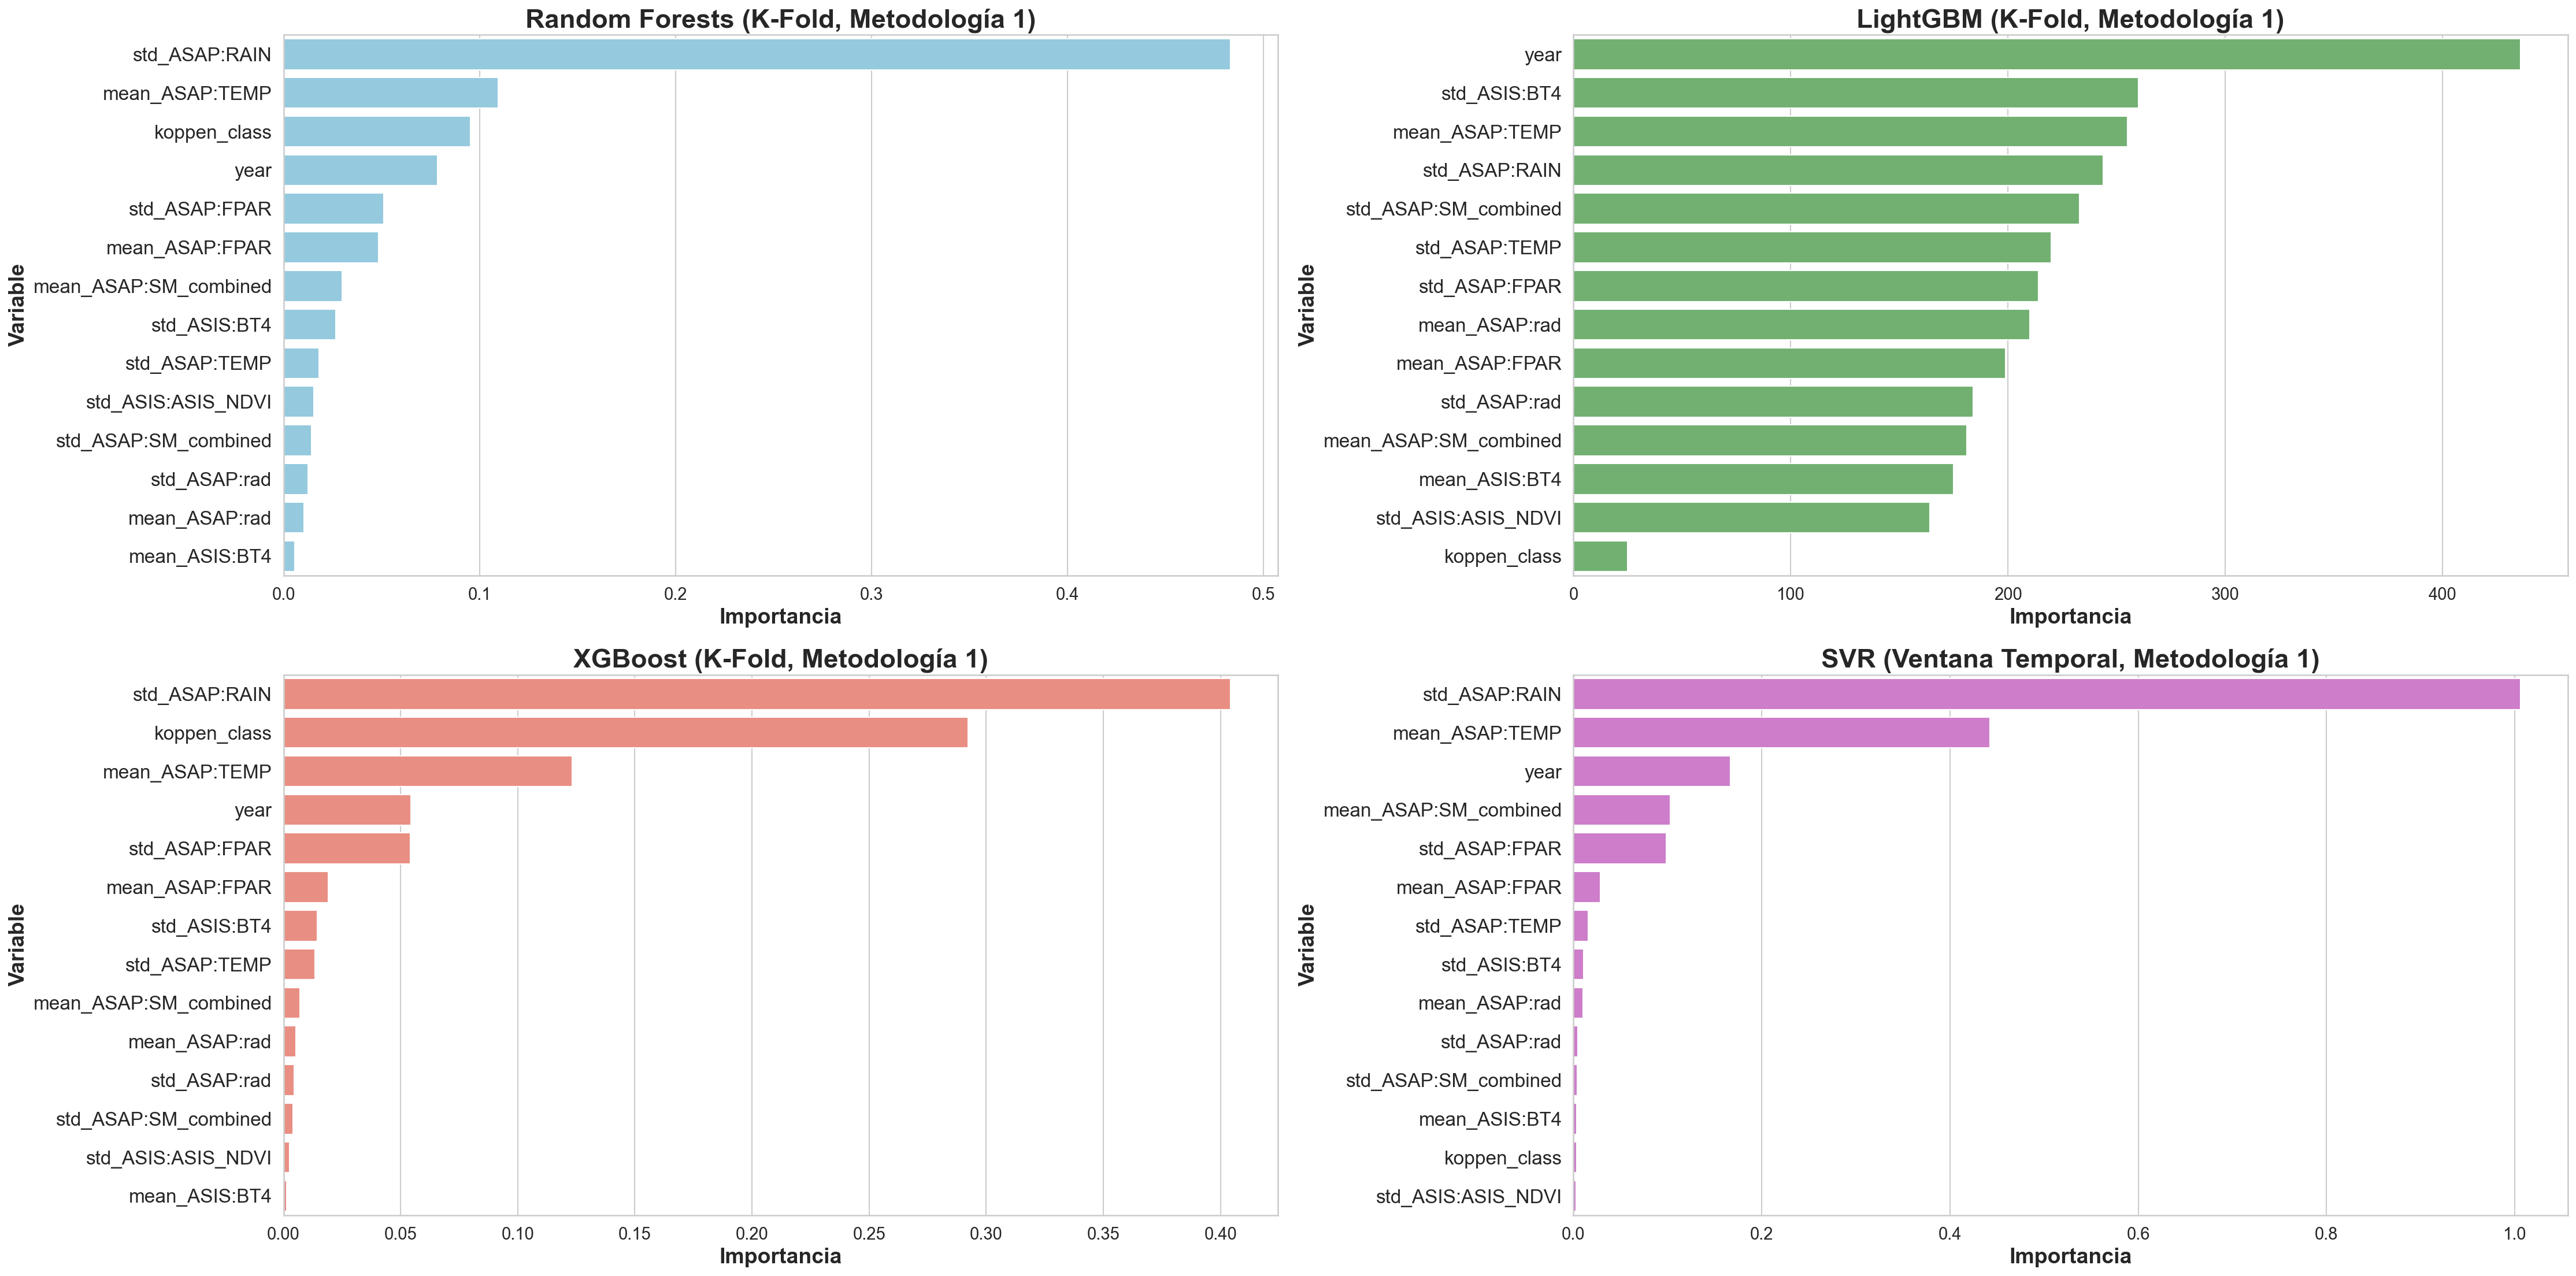

In [25]:
X_arroz = arroz[col_names_train_rice[:-1] + ["year"]]

fig, axes = plt.subplots(2, 2, figsize=(30, 15))


# Random Forests
model_arroz_rf = training_kfold_arroz_rf1
importances_rf = model_arroz_rf.feature_importances_

imp_rf = pd.DataFrame({
    "Variable": X_arroz.columns,
    "Importancia": importances_rf
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_rf,
    x="Importancia",
    y="Variable",
    ax=axes[0, 0],
    color="skyblue"
)
axes[0, 0].set_title("Random Forests (K-Fold, Metodología 1)")


# LightGBM
model_arroz_lgb = training_kfold_arroz_lgb1 
importances_lgb = model_arroz_lgb.feature_importances_

imp_lgb = pd.DataFrame({
    "Variable": X_arroz.columns,
    "Importancia": importances_lgb
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_lgb,
    x="Importancia",
    y="Variable",
    ax=axes[0, 1],
    color="#66bb66"
)
axes[0, 1].set_title("LightGBM (K-Fold, Metodología 1)")


# XGBoost
model_arroz_xgb = training_kfold_arroz_xgb1 
importances_xgb = model_arroz_xgb.feature_importances_
imp_xgb = pd.DataFrame({
    "Variable": X_arroz.columns,
    "Importancia": importances_xgb
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_xgb,
    x="Importancia",
    y="Variable",
    ax=axes[1, 0],
    color="salmon"
)
axes[1, 0].set_title("XGBoost (K-Fold, Metodología 1)")


# SVR - Al no tener un kernel lineal (poly, rbf o sigmoid), aplicamos Permutation Importance 
model_arroz_svr = training_vent_arroz_svr1 
result = permutation_importance(model_arroz_svr, X_arroz, arroz['yield'], n_repeats=30, random_state=42) 
importances_svr = result.importances_mean

imp_svr = pd.DataFrame({
    "Variable": X_arroz.columns,
    "Importancia": importances_svr
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_svr,
    x="Importancia",
    y="Variable",
    ax=axes[1, 1],
    color="orchid"
)
axes[1, 1].set_title("SVR (Ventana Temporal, Metodología 1)")

for ax in axes.flat:
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=14)

plt.tight_layout()
plt.savefig("Figuras/imp_var_arrozxmodelo.svg", format="svg", bbox_inches="tight")
plt.savefig("Figuras/imp_var_arrozxmodelo.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Maíz

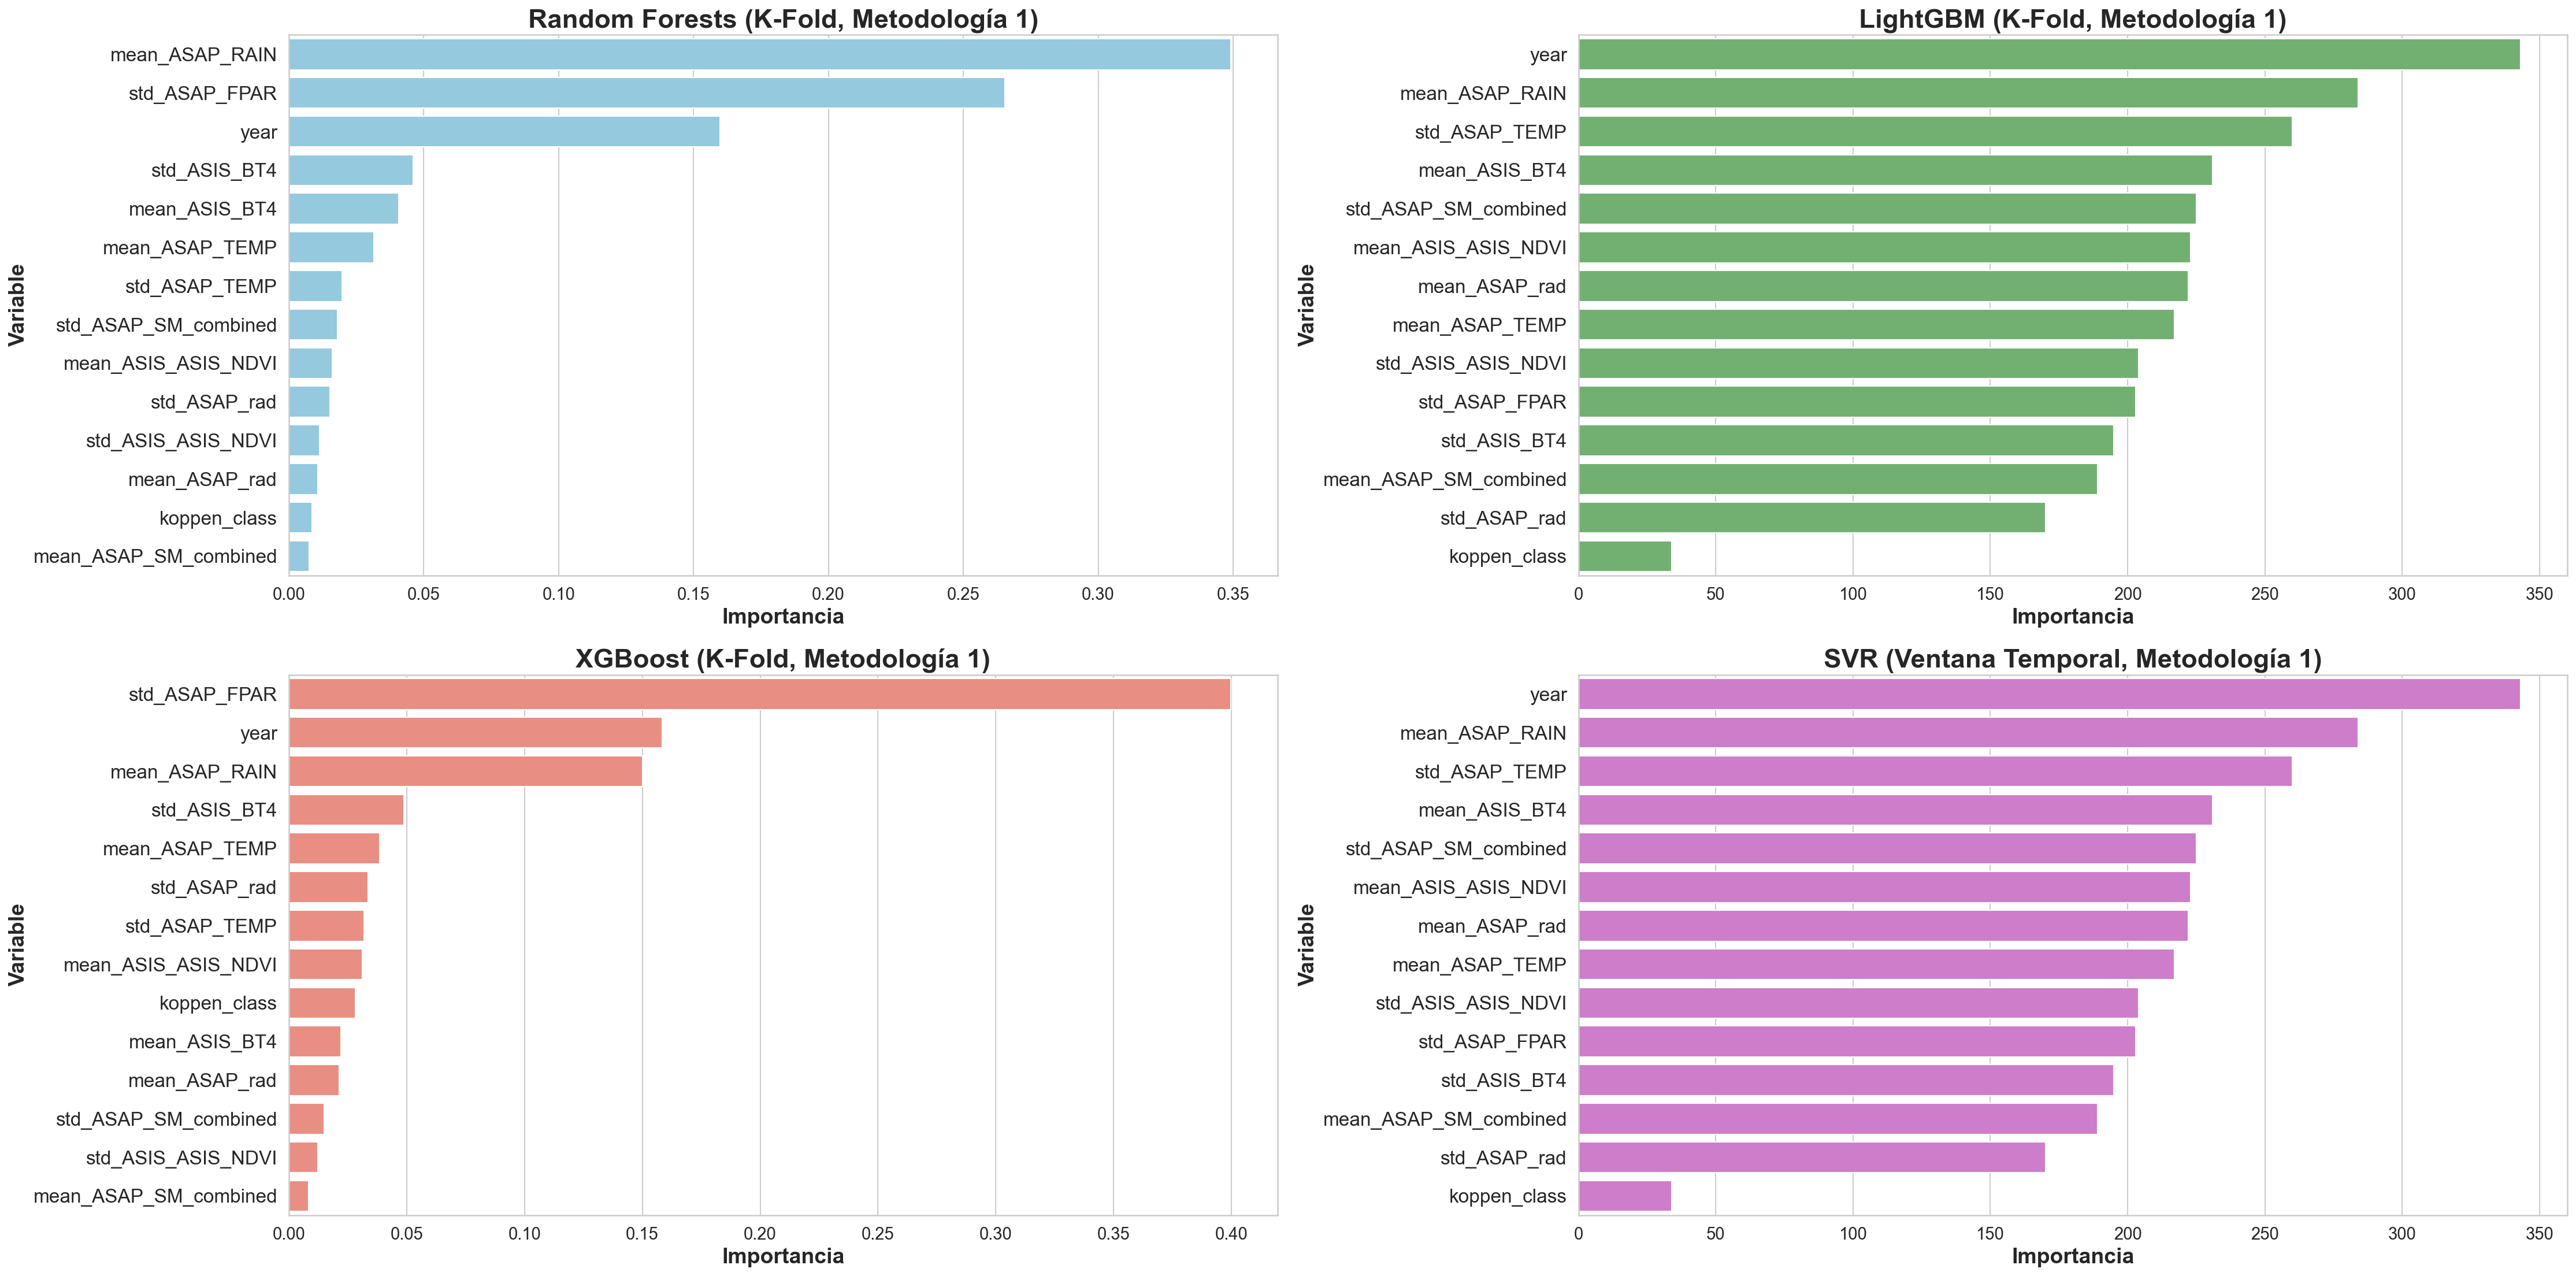

In [26]:
X_maiz = maiz[col_names_train_maize[:-1] + ["year"]]
X_maiz.columns = X_maiz.columns.str.replace(':', '_', regex=False)

fig, axes = plt.subplots(2, 2, figsize=(30, 15))


# Random Forests
model_maiz_rf = training_kfold_maiz_rf1
importances_rf = model_maiz_rf.feature_importances_

imp_rf = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_rf
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_rf,
    x="Importancia",
    y="Variable",
    ax=axes[0, 0],
    color="skyblue"
)
axes[0, 0].set_title("Random Forests (K-Fold, Metodología 1)")


# LightGBM
model_maiz_lgb = training_kfold_maiz_lgb1
importances_lgb = model_maiz_lgb.feature_importances_

imp_lgb = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_lgb
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_lgb,
    x="Importancia",
    y="Variable",
    ax=axes[0, 1],
    color="#66bb66"
)
axes[0, 1].set_title("LightGBM (K-Fold, Metodología 1)")


# XGBoost
model_maiz_xgb = training_kfold_maiz_xgb1
importances_xgb = model_maiz_xgb.feature_importances_

imp_xgb = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_xgb
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_xgb,
    x="Importancia",
    y="Variable",
    ax=axes[1, 0],
    color="salmon"
)
axes[1, 0].set_title("XGBoost (K-Fold, Metodología 1)")


# SVR - Kernel lineal, NO aplicamos Permutation Importance
model_maiz_svr = training_vent_maiz_svr1
importances_svr = model_maiz_svr.feature_importances_

imp_svr = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_svr
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_svr,
    x="Importancia",
    y="Variable",
    ax=axes[1, 1],
    color="orchid",
)
axes[1, 1].set_title("SVR (Ventana Temporal, Metodología 1)")

for ax in axes.flat:
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=14)

plt.tight_layout()
plt.savefig("Figuras/imp_var_maizxmodelo.svg", format="svg", bbox_inches="tight")
plt.savefig("Figuras/imp_var_maizxmodelo.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Trigo

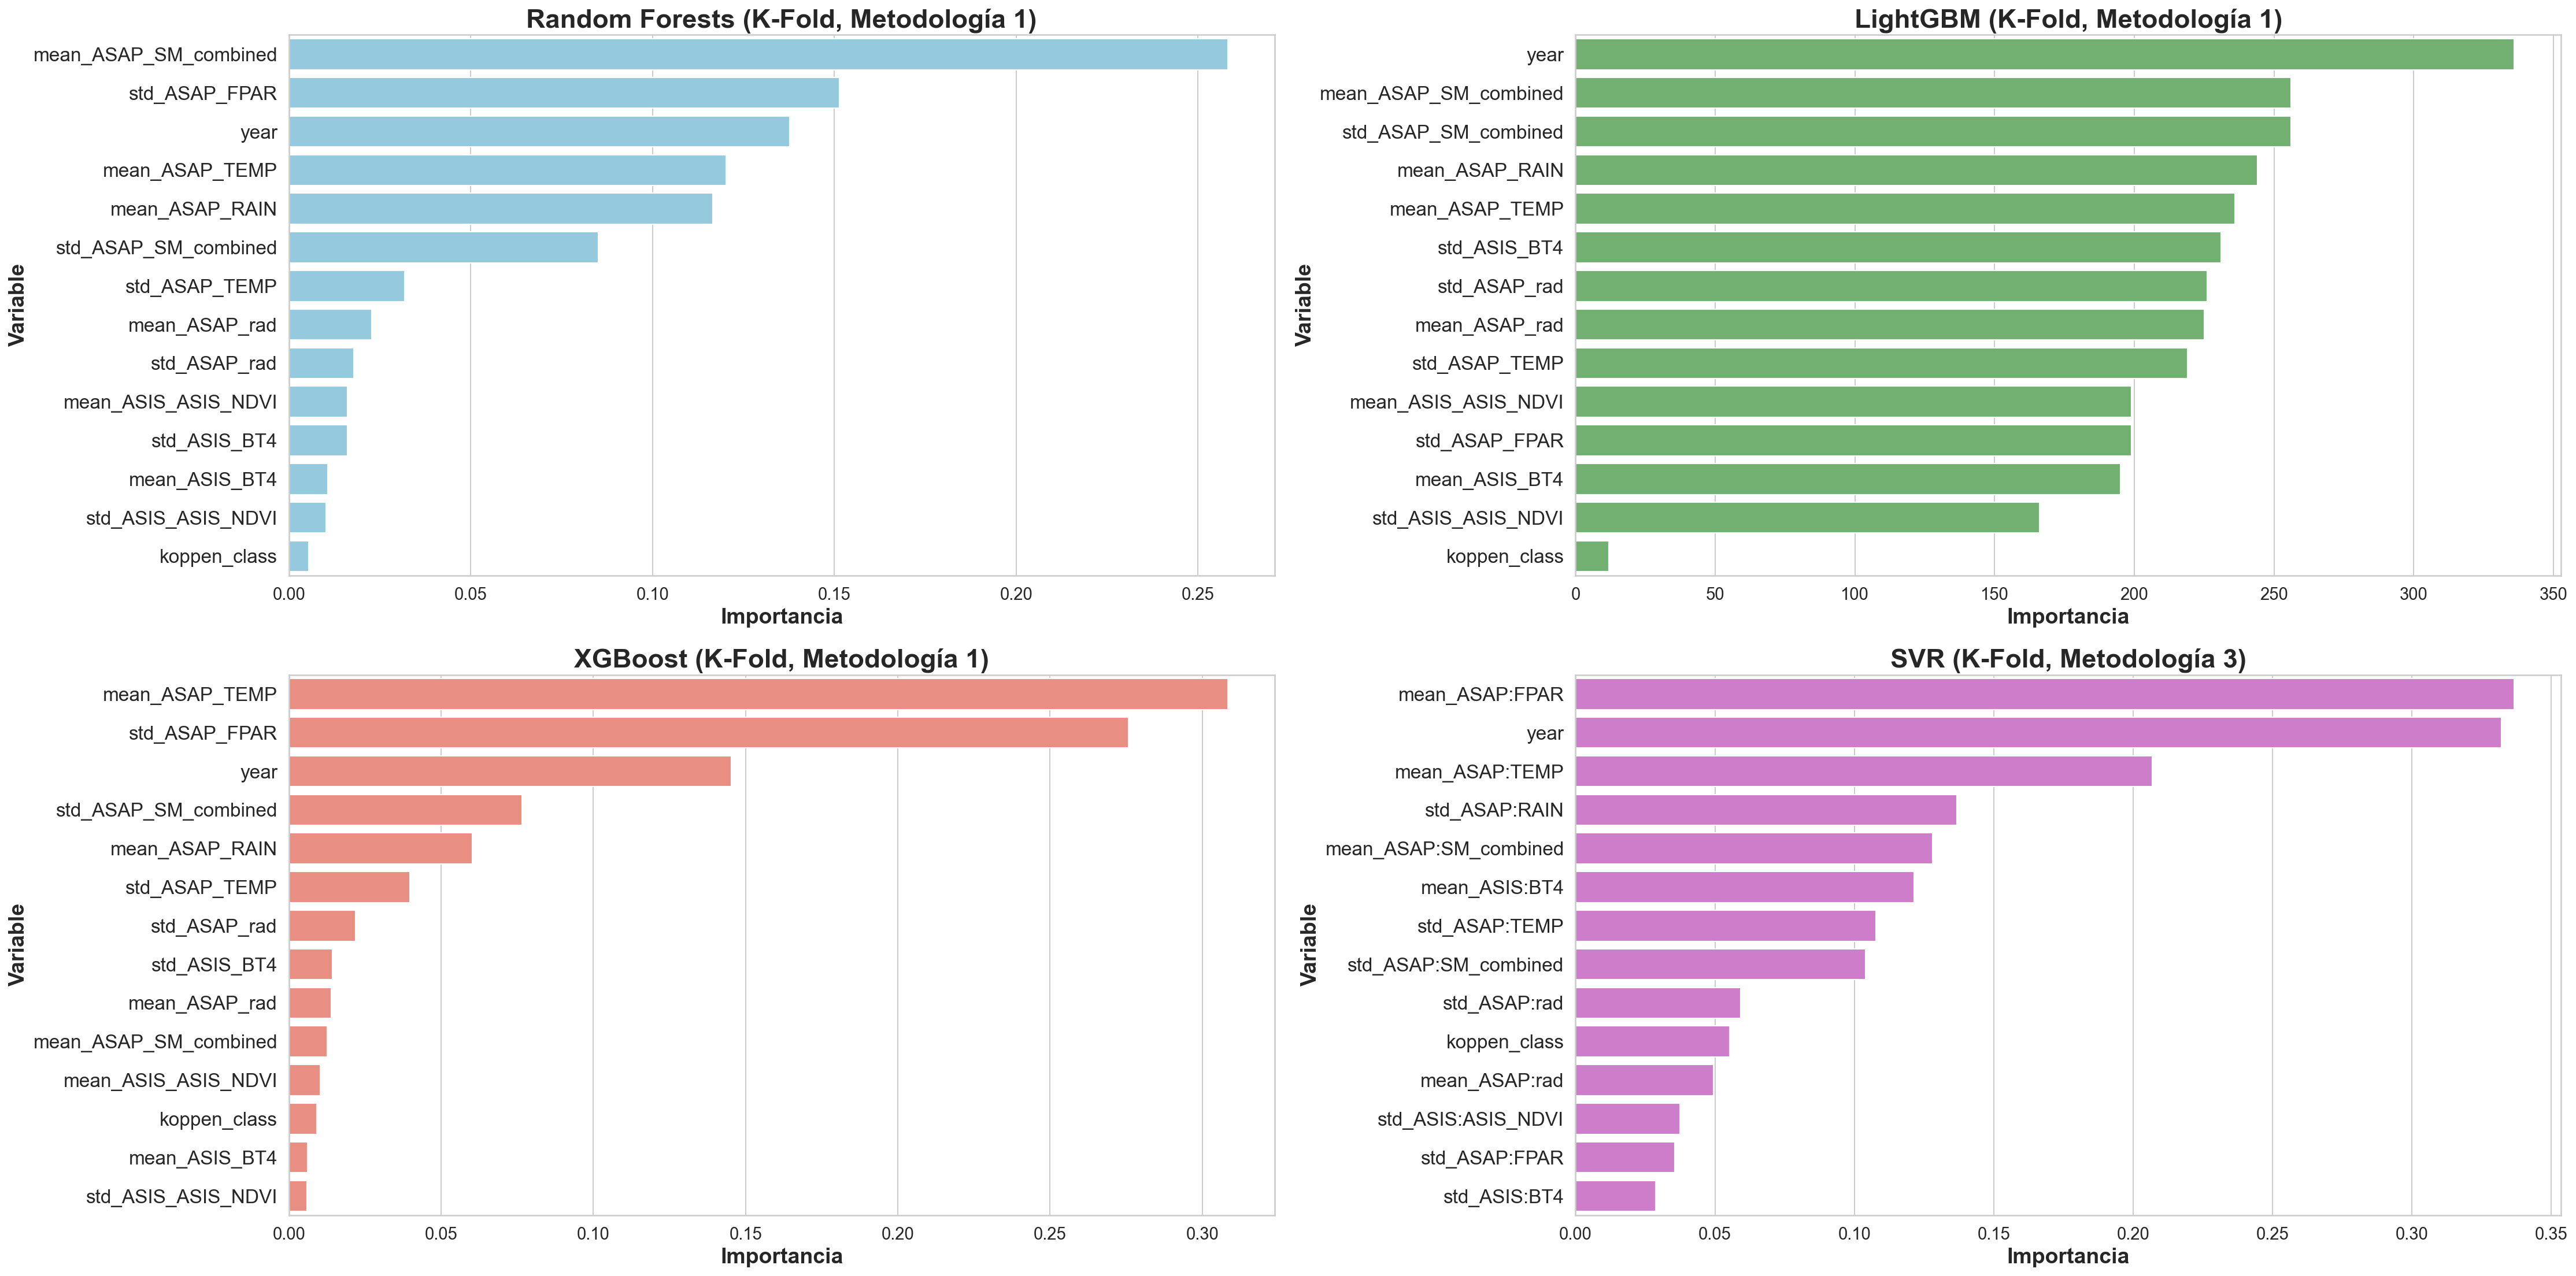

In [27]:
X_trigo = trigo[col_names_train_wheat[:-1] + ["year"]]
X_trigo.columns = X_trigo.columns.str.replace(':', '_', regex=False)

fig, axes = plt.subplots(2, 2, figsize=(30, 15))


# Random Forests
model_trigo_rf = training_kfold_trigo_rf1
importances_rf = model_trigo_rf.feature_importances_

imp_rf = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_rf
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_rf,
    x="Importancia",
    y="Variable",
    ax=axes[0, 0],
    color="skyblue"
)
axes[0, 0].set_title("Random Forests (K-Fold, Metodología 1)")


# LightGBM
model_trigo_lgb = training_kfold_trigo_lgb1
importances_lgb = model_trigo_lgb.feature_importances_

imp_lgb = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_lgb
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_lgb,
    x="Importancia",
    y="Variable",
    ax=axes[0, 1],
    color="#66bb66"
)
axes[0, 1].set_title("LightGBM (K-Fold, Metodología 1)")


# XGBoost
model_trigo_xgb = training_kfold_trigo_xgb1
importances_xgb = model_trigo_xgb.feature_importances_

imp_xgb = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_xgb
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_xgb,
    x="Importancia",
    y="Variable",
    ax=axes[1, 0],
    color="salmon"
)
axes[1, 0].set_title("XGBoost (K-Fold, Metodología 1)")


# SVR - Kernel no lineal (poly, rbf o sigmoid), aplicamos Permutation Importance
model_trigo_svr = training_kfold_trigo_svr3
result = permutation_importance(model_trigo_svr, X_trigo, trigo['yield'], n_repeats=30, random_state=42)
importances_svr = result.importances_mean

imp_svr = pd.DataFrame({
    "Variable": X_arroz.columns,
    "Importancia": importances_svr
}).sort_values("Importancia", ascending=False)

sns.barplot(
    data=imp_svr,
    x="Importancia",
    y="Variable",
    ax=axes[1, 1],
    color="orchid"
)
axes[1, 1].set_title("SVR (K-Fold, Metodología 3)")

for ax in axes.flat:
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=14)

plt.tight_layout()
plt.savefig("Figuras/imp_var_trigoxmodelo.svg", format="svg", bbox_inches="tight")
plt.savefig("Figuras/imp_var_trigoxmodelo.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Análisis del mejor modelo por cultivo (Features importance)

Contrariamente a la idea que se tenía en un principio, el análisis de cada tipo de modelo aporta variedad al estudio a la vez que confusión sobre cuál actúa mejor. Seleccionaremos y estudiaremos ahora el modelo que consideramos mejores resultados obtiene.

In [28]:
def mejores_combinaciones(df_orig, metric):

    if metric == "rRMSE":
        return df_orig.loc[df_orig.groupby("Cultivo")[metric].idxmin()]
    elif metric == "nME":
        # Calcula el índice del valor más cercano a cero por cultivo
        idx = df_orig.groupby("Cultivo")[metric].apply(lambda x: (x.abs()).idxmin())
        return df_orig.loc[idx.values]
    else:
        raise ValueError("La métrica debe ser 'rRMSE' o 'nME'")

In [29]:
mejores_combinaciones(df_total, "rRMSE")

,Modelo,Metodología,Cultivo,Estrategia,rRMSE,nME
18,Random Forests,1,Arroz,KFold,7.160610,-0.010396
20,Random Forests,1,Maíz,KFold,14.915564,-0.041429
22,Random Forests,1,Trigo,KFold,13.833128,-0.031445


In [30]:
mejores_combinaciones(df_total, "nME")

,Modelo,Metodología,Cultivo,Estrategia,rRMSE,nME
25,Random Forests,2,Arroz,Ventana,13.263506,-0.001272
21,Random Forests,1,Maíz,Ventana,17.654592,0.003185
34,Random Forests,3,Trigo,KFold,15.781472,-0.001221


Seleccionamos los modelos con menor rRMSE ya que esta es una unidad que nos indica el error relativo porcentual, lo que significa que podemos usarla para evaluar conjuntos de datos heterogéneos. Teniendo esto en mente nos quedaremos con los modelos de Random Forest con K-Fold y metodología 1 (agrupación por país) para cada cultivo.

In [31]:
# 1. Función para agrupar variables por familia
def obtener_grupo(var):

    if var == "year":
        return "Temporal"

    elif var == "koppen_class":
        return "Contexto climático"

    elif ("NDVI" in var) or ("FPAR" in var):
        return "Vegetación"

    elif ("TEMP" in var) or ("BT4" in var):
        return "Temperatura / térmica"

    elif ("RAIN" in var) or ("SM_combined" in var) or ("SM" in var):
        return "Agua / humedad"

    elif "rad" in var:
        return "Radiación"

    else:
        return "Otros"


# 2. Paleta común para los tres cultivos
palette = {
    "Vegetación": "#2ca02c",
    "Temperatura / térmica": "#d62728",
    "Agua / humedad": "#1f77b4",
    "Radiación": "#ff7f0e",
    "Contexto climático": "#9467bd",
    "Temporal": "#8c564b",
    "Dispersión espacial": "#7f7f7f",
    "Otros": "#000000"
}

#### Arroz

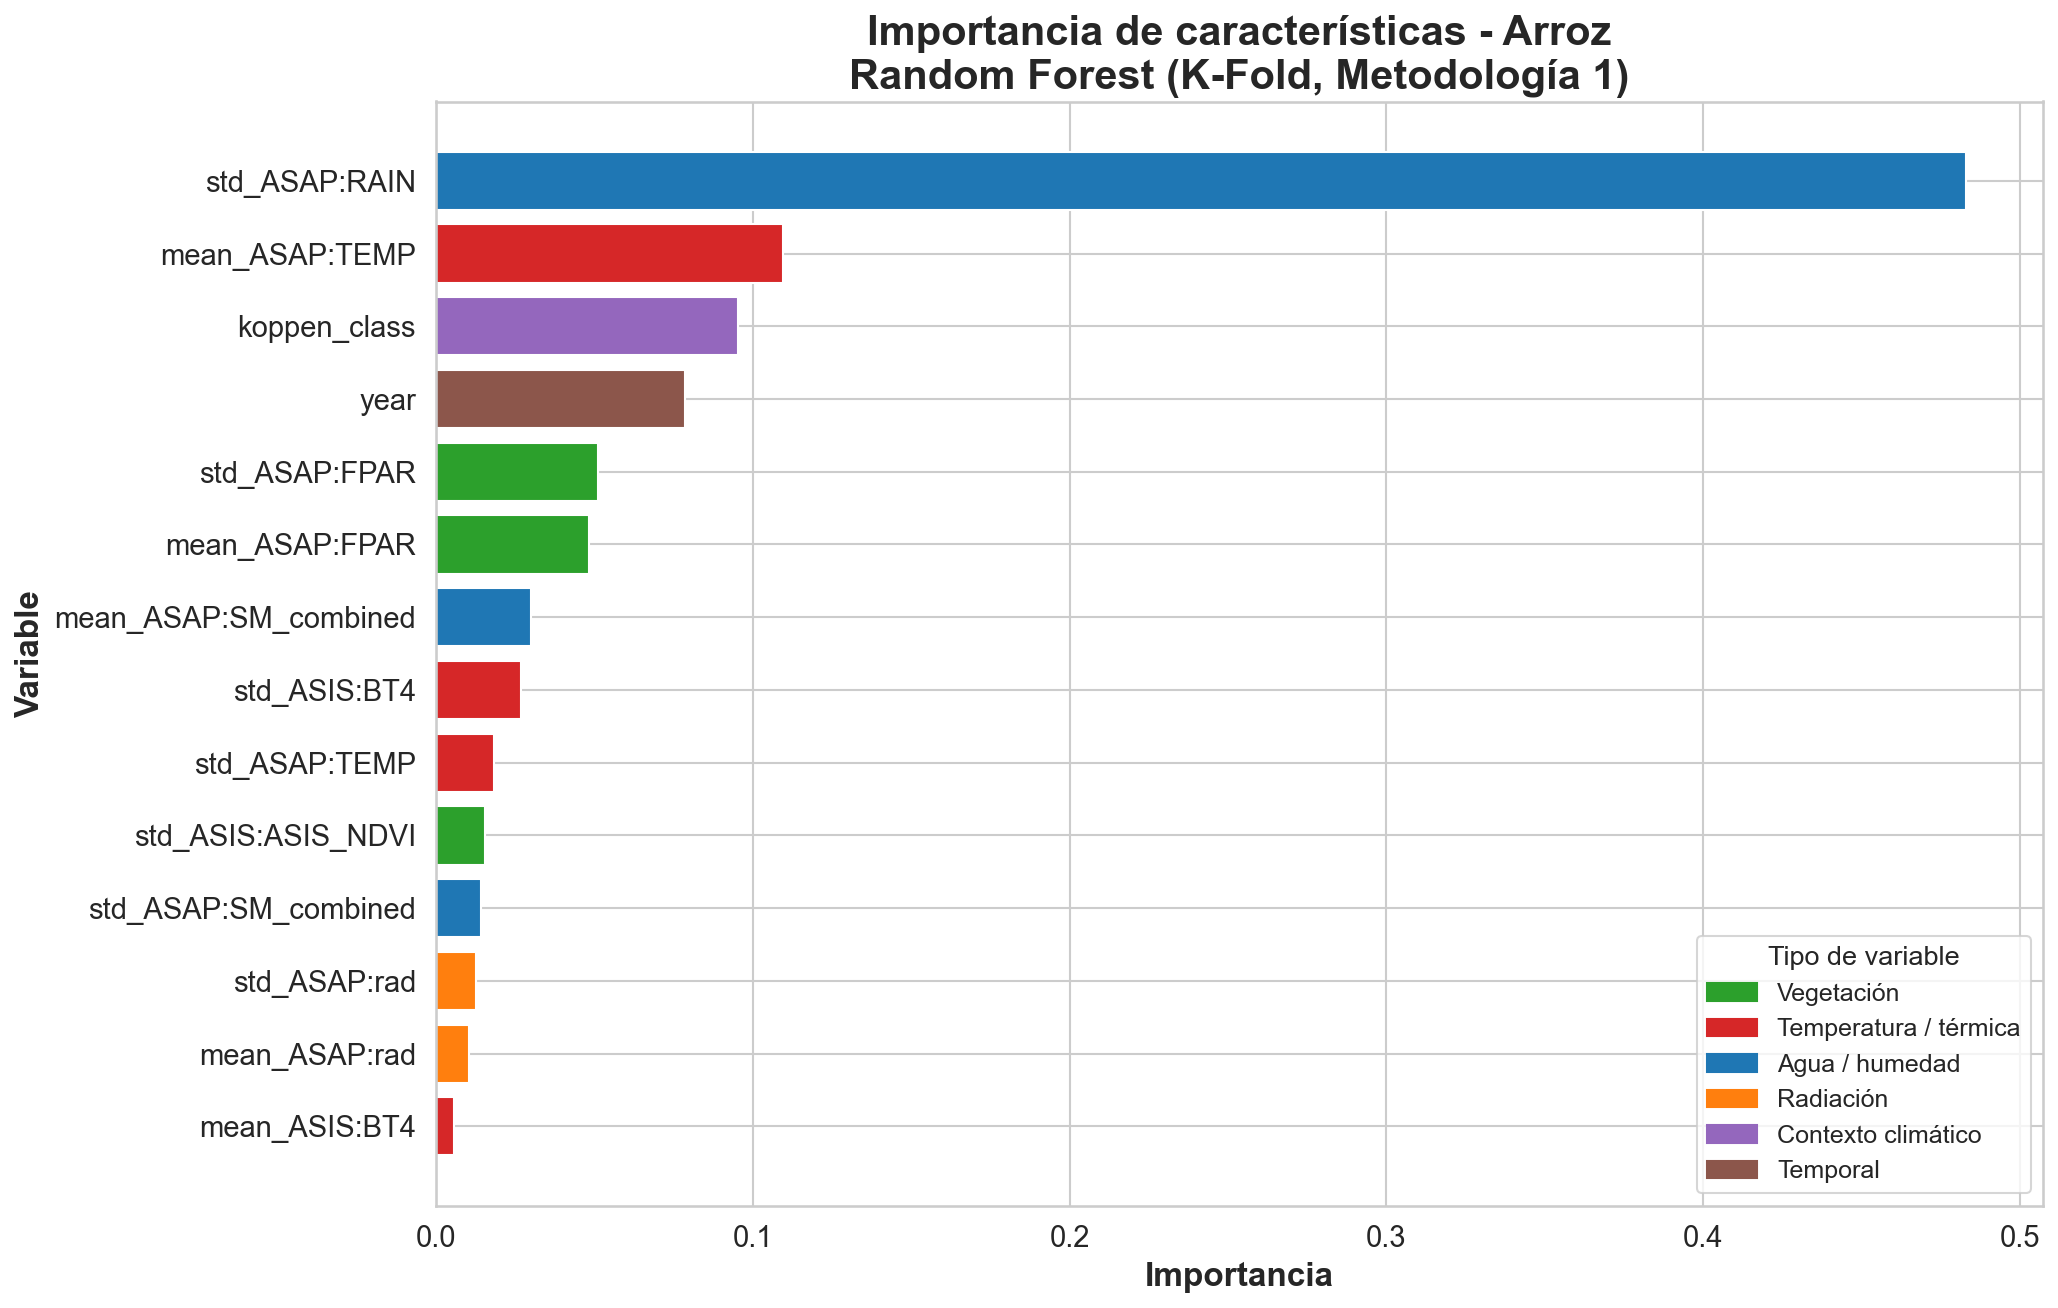

In [32]:
X_arroz = arroz[col_names_train_rice[:-1] + ["year"]]

model_arroz_rf = training_kfold_arroz_rf1
importances_rf = model_arroz_rf.feature_importances_

df_imp_arroz = pd.DataFrame({
    "Variable": X_arroz.columns,
    "Importancia": importances_rf
})

df_imp_arroz["Grupo"] = df_imp_arroz["Variable"].apply(obtener_grupo)
df_imp_arroz = df_imp_arroz.sort_values("Importancia", ascending=False)

colors = [palette[g] for g in df_imp_arroz["Grupo"]]

plt.figure(figsize=(14, 9))

plt.barh(
    df_imp_arroz["Variable"],
    df_imp_arroz["Importancia"],
    color=colors
)

plt.gca().invert_yaxis()

plt.title(
    "Importancia de características - Arroz\nRandom Forest (K-Fold, Metodología 1)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Importancia", fontsize=16, fontweight="bold")
plt.ylabel("Variable", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

handles = [
    Patch(color=color, label=grupo)
    for grupo, color in palette.items()
    if grupo in df_imp_arroz["Grupo"].unique()
]

plt.legend(
    handles=handles,
    title="Tipo de variable",
    fontsize=12,
    title_fontsize=13,
    loc="lower right"
)

plt.tight_layout()

plt.savefig("Figuras/imp_var_bestconfig_arroz.svg", format="svg", bbox_inches="tight")
plt.savefig("Figuras/imp_var_bestconfig_arroz.pdf", format="pdf", bbox_inches="tight")

plt.show()

#### Maíz

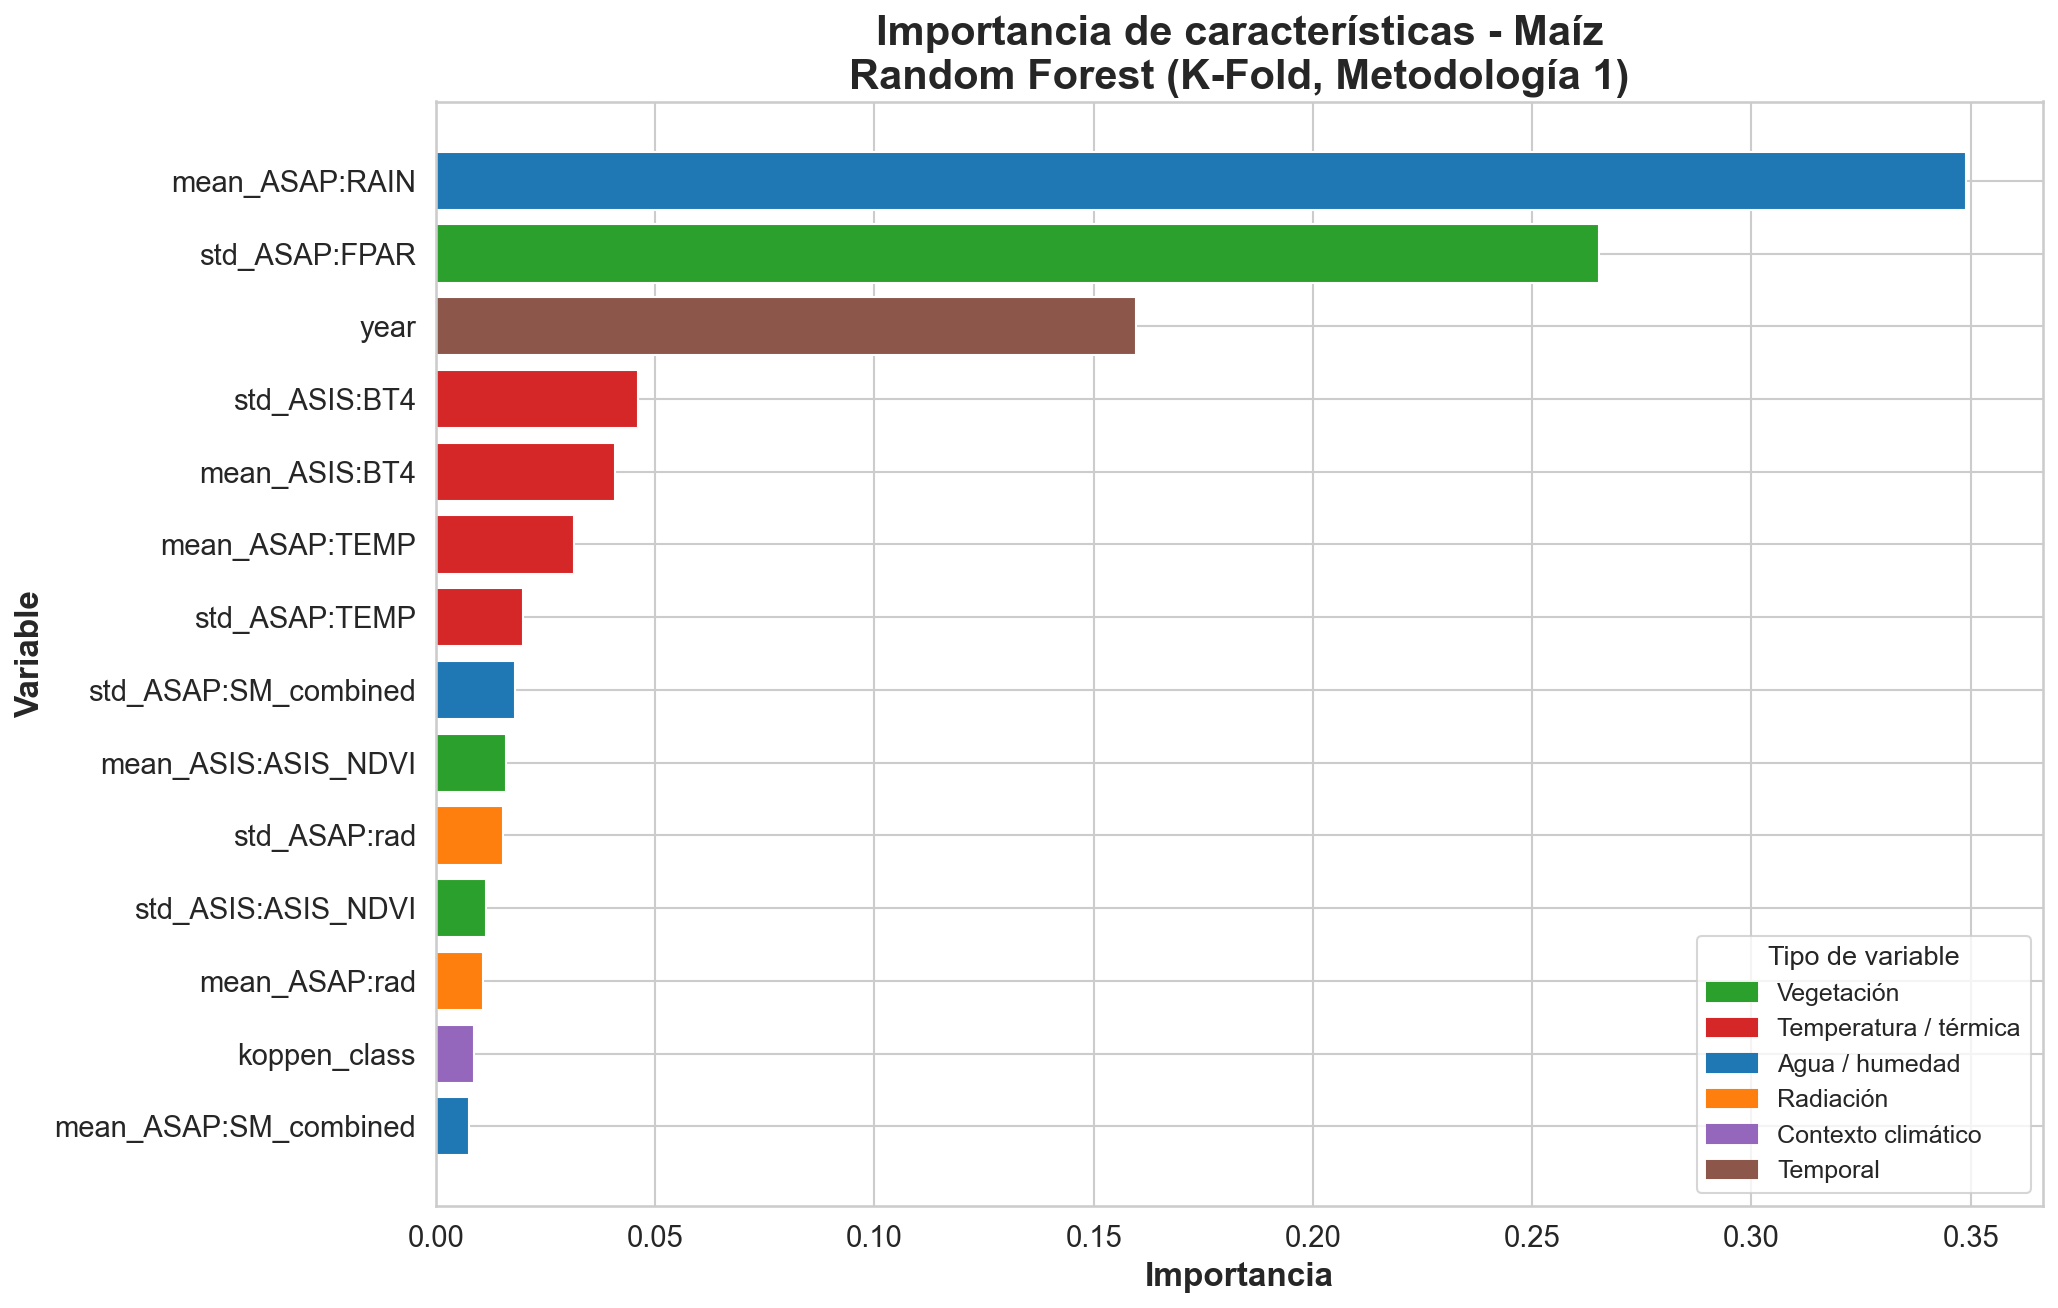

In [33]:
X_maiz = maiz[col_names_train_maize[:-1] + ["year"]]

model_maiz_rf = training_kfold_maiz_rf1
importances_rf = model_maiz_rf.feature_importances_

df_imp_maiz = pd.DataFrame({
    "Variable": X_maiz.columns,
    "Importancia": importances_rf
})

df_imp_maiz["Grupo"] = df_imp_maiz["Variable"].apply(obtener_grupo)
df_imp_maiz = df_imp_maiz.sort_values("Importancia", ascending=False)

colors = [palette[g] for g in df_imp_maiz["Grupo"]]

plt.figure(figsize=(14, 9))

plt.barh(
    df_imp_maiz["Variable"],
    df_imp_maiz["Importancia"],
    color=colors
)

plt.gca().invert_yaxis()

plt.title(
    "Importancia de características - Maíz\nRandom Forest (K-Fold, Metodología 1)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Importancia", fontsize=16, fontweight="bold")
plt.ylabel("Variable", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

handles = [
    Patch(color=color, label=grupo)
    for grupo, color in palette.items()
    if grupo in df_imp_maiz["Grupo"].unique()
]

plt.legend(
    handles=handles,
    title="Tipo de variable",
    fontsize=12,
    title_fontsize=13,
    loc="lower right"
)

plt.tight_layout()

plt.savefig("Figuras/imp_var_bestconfig_maiz.svg", format="svg", bbox_inches="tight")
plt.savefig("Figuras/imp_var_bestconfig_maiz.pdf", format="pdf", bbox_inches="tight")

plt.show()

#### Trigo

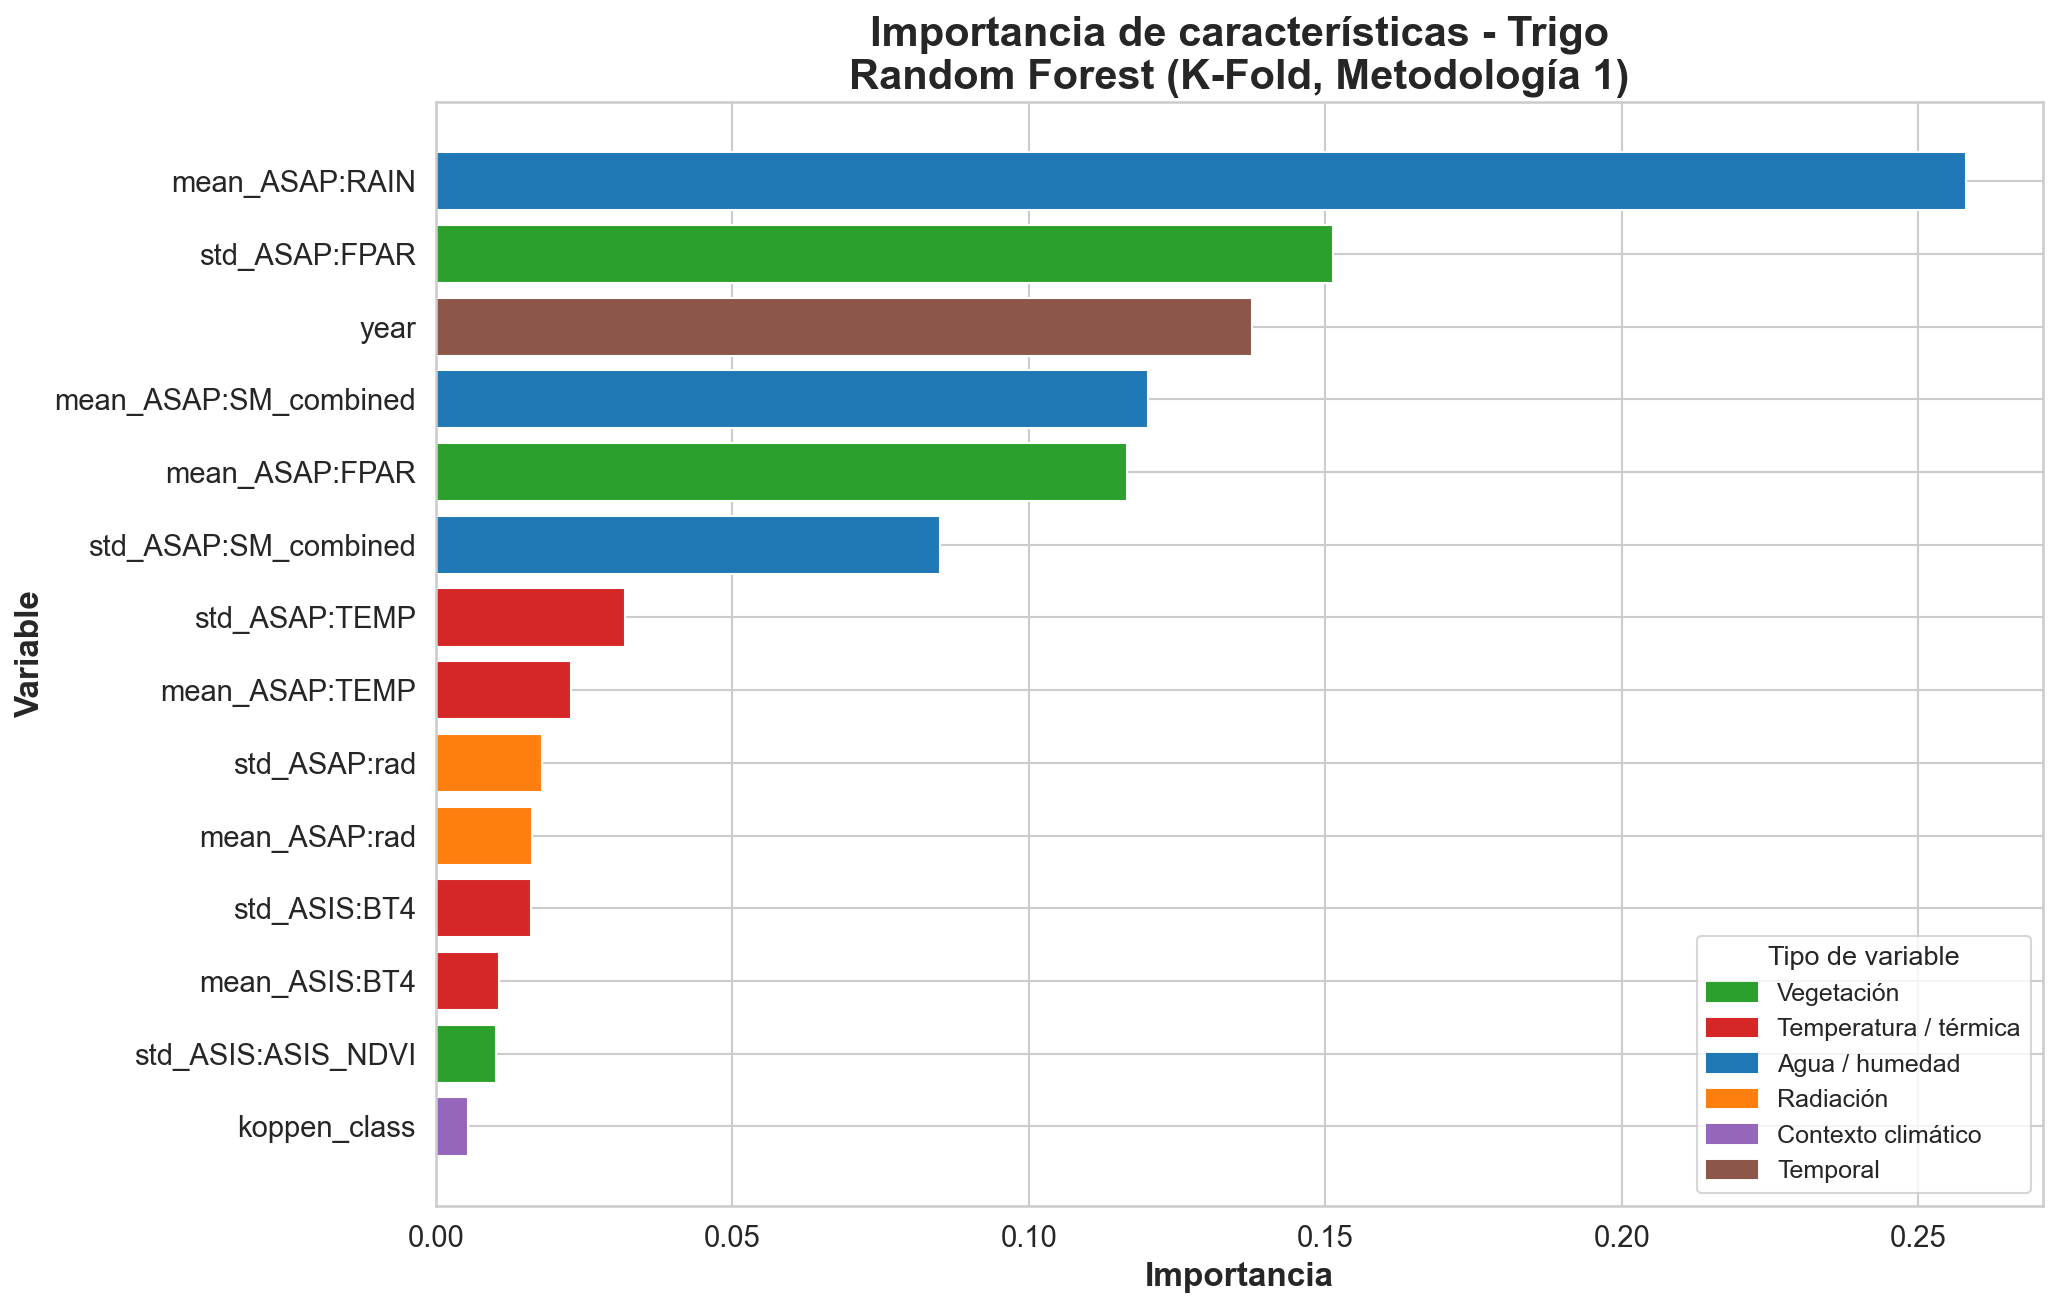

In [34]:
X_trigo = trigo[col_names_train_wheat[:-1] + ["year"]]

model_trigo_rf = training_kfold_trigo_rf1
importances_rf = model_trigo_rf.feature_importances_

df_imp_trigo = pd.DataFrame({
    "Variable": X_trigo.columns,
    "Importancia": importances_rf
})

df_imp_trigo["Grupo"] = df_imp_trigo["Variable"].apply(obtener_grupo)
df_imp_trigo = df_imp_trigo.sort_values("Importancia", ascending=False)

colors = [palette[g] for g in df_imp_trigo["Grupo"]]

plt.figure(figsize=(14, 9))

plt.barh(
    df_imp_trigo["Variable"],
    df_imp_trigo["Importancia"],
    color=colors
)

plt.gca().invert_yaxis()

plt.title(
    "Importancia de características - Trigo\nRandom Forest (K-Fold, Metodología 1)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Importancia", fontsize=16, fontweight="bold")
plt.ylabel("Variable", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

handles = [
    Patch(color=color, label=grupo)
    for grupo, color in palette.items()
    if grupo in df_imp_trigo["Grupo"].unique()
]

plt.legend(
    handles=handles,
    title="Tipo de variable",
    fontsize=12,
    title_fontsize=13,
    loc="lower right"
)

plt.tight_layout()

plt.savefig("Figuras/imp_var_bestconfig_trigo.svg", format="svg", bbox_inches="tight")
plt.savefig("Figuras/imp_var_bestconfig_trigo.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Trabajo complementario (Anexo)

In [35]:
def crear_tabla_resumen_experimental(
    guardar=True,
    ruta_base="Figuras/tabla_resumen_experimental"
):
    """
    Crea, guarda y muestra una tabla resumen del diseño experimental del estudio.
    """

    datos = [
        {
            "Elemento": "Cultivos",
            "Opciones consideradas": "Maíz, arroz y trigo",
            "Descripción": "Cultivos seleccionados para la estimación del rendimiento agrícola."
        },
        {
            "Elemento": "Modelos",
            "Opciones consideradas": "Random Forest, XGBoost, LightGBM y SVR",
            "Descripción": "Modelos de regresión supervisada empleados para comparar diferentes enfoques de aprendizaje automático."
        },
        {
            "Elemento": "Estrategias de entrenamiento",
            "Opciones consideradas": "K-Fold por años y ventana temporal",
            "Descripción": "K-Fold excluye un año para validación y entrena con el resto; la ventana temporal predice cada año utilizando únicamente información de años anteriores."
        },
        {
            "Elemento": "Metodologías de agrupación",
            "Opciones consideradas": "Por país, por clase Köppen y sin agrupar",
            "Descripción": "Permiten evaluar si el rendimiento mejora al entrenar modelos específicos por país, modelos agrupados por contexto climático o modelos globales."
        },
        {
            "Elemento": "Métricas principales",
            "Opciones consideradas": "rRMSE y nME",
            "Descripción": "rRMSE mide la magnitud relativa del error y nME permite interpretar el sesgo medio de las predicciones."
        }
    ]

    df_tabla = pd.DataFrame(datos)

    # Ajuste de texto por columna
    wrap_config = {
        "Elemento": 24,
        "Opciones consideradas": 36,
        "Descripción": 70
    }

    for col, width in wrap_config.items():
        df_tabla[col] = df_tabla[col].apply(
            lambda x: "\n".join(textwrap.wrap(str(x), width=width))
        )

    fig, ax = plt.subplots(figsize=(24, 9))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_tabla.values,
        colLabels=df_tabla.columns,
        cellLoc="left",
        colLoc="center",
        loc="center",
        colWidths=[0.22, 0.31, 0.47]
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(18)
    tabla.scale(1.05, 1.0)

    n_columnas = len(df_tabla.columns)

    # Cabecera
    for col in range(n_columnas):
        cell = tabla[(0, col)]
        cell.set_facecolor("#3f486f")
        cell.set_text_props(
            weight="bold",
            color="white",
            fontsize=22,
            ha="center",
            va="center"
        )
        cell.set_height(0.13)

    # Filas
    altura_base = 0.07
    altura_minima = 0.12

    for row in range(1, len(df_tabla) + 1):

        max_lineas = max(
            str(df_tabla.iloc[row - 1, col]).count("\n") + 1
            for col in range(n_columnas)
        )

        altura_fila = max(altura_minima, altura_base * max_lineas)

        for col in range(n_columnas):
            cell = tabla[(row, col)]
            cell.set_height(altura_fila)
            cell.set_text_props(va="center")

            if row % 2 == 0:
                cell.set_facecolor("#f2f2f2")
            else:
                cell.set_facecolor("white")


    plt.tight_layout()

    if guardar:
        plt.savefig(f"{ruta_base}.svg", format="svg", bbox_inches="tight")
        plt.savefig(f"{ruta_base}.pdf", format="pdf", bbox_inches="tight")
        plt.savefig(f"{ruta_base}.png", format="png", dpi=300, bbox_inches="tight")

    plt.show()

    return df_tabla

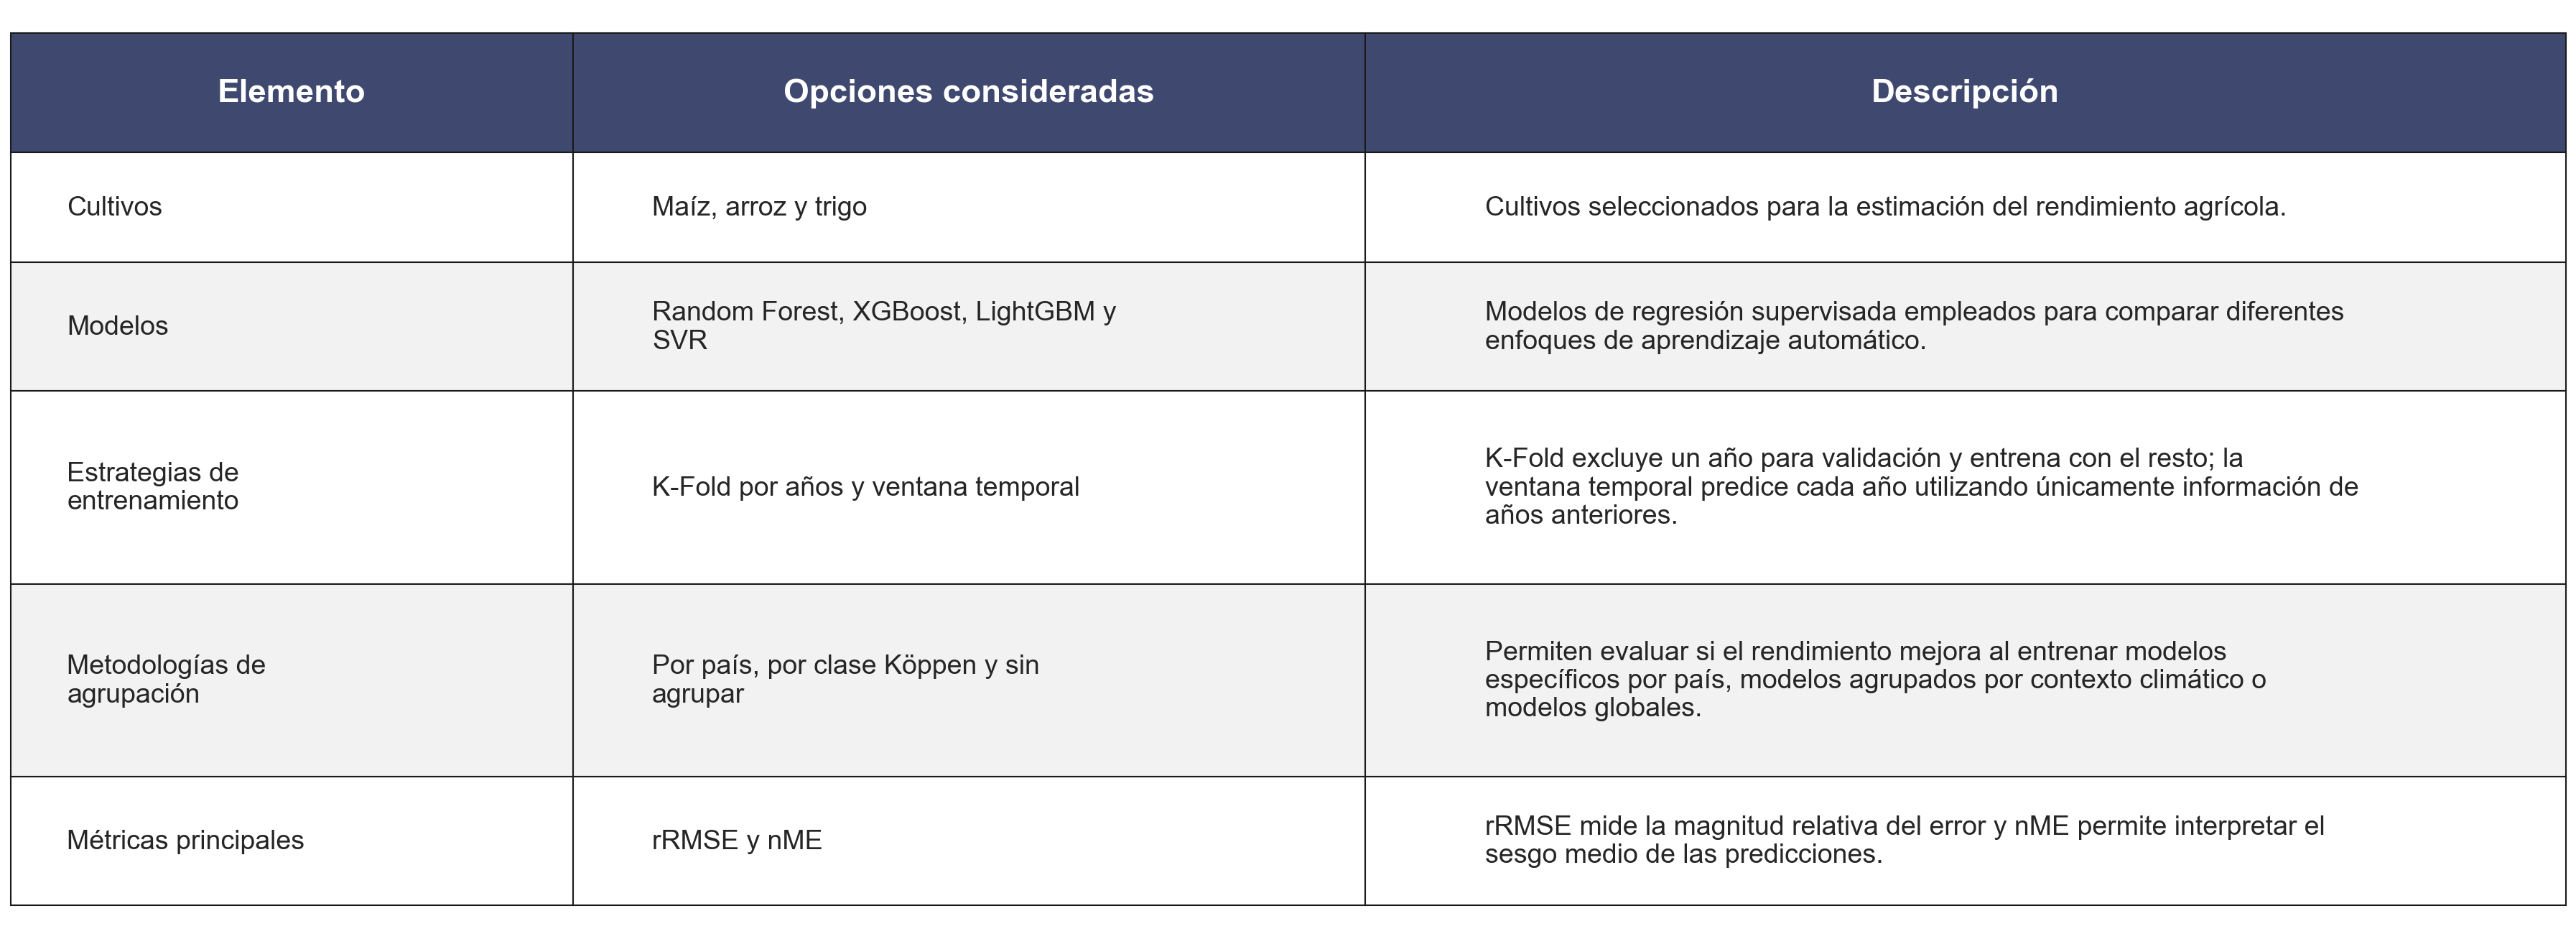

In [36]:
tabla_resumen = crear_tabla_resumen_experimental()

In [37]:
def crear_tabla_svr_final(
    guardar=True,
    ruta_base="Figuras/tabla_svr_final"
):
    """
    Crea, guarda y muestra la tabla con la configuración final seleccionada para SVR.
    """

    datos = [
        ["Maíz", "Optimización Bayesiana", "linear", 12.110, 0.01, 0.0001, 1012.31],
        ["Arroz", "Optimización Bayesiana", "rbf", 26.038, 0.01, 0.0489, 1441.39],
        ["Trigo", "Optimización Bayesiana", "poly", 100.000, 0.01, 0.1000, 1182.71]
    ]

    columnas = [
        "Cultivo",
        "Método seleccionado",
        "Kernel",
        "C",
        "epsilon",
        "gamma",
        "RMSE de validación"
    ]

    df_tabla = pd.DataFrame(datos, columns=columnas)

    # Formato numérico
    df_tabla["C"] = df_tabla["C"].map(lambda x: f"{x:.3f}")
    df_tabla["epsilon"] = df_tabla["epsilon"].map(lambda x: f"{x:.2f}")
    df_tabla["gamma"] = df_tabla["gamma"].map(lambda x: f"{x:.4f}")
    df_tabla["RMSE de validación"] = df_tabla["RMSE de validación"].map(lambda x: f"{x:.2f}")

    fig, ax = plt.subplots(figsize=(22, 2))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_tabla.values,
        colLabels=df_tabla.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=[0.11, 0.27, 0.11, 0.09, 0.11, 0.11, 0.20]
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(17)
    tabla.scale(1.05, 2.4)

    n_columnas = len(df_tabla.columns)

    # Cabecera
    for col in range(n_columnas):
        cell = tabla[(0, col)]
        cell.set_facecolor("#3f486f")
        cell.set_text_props(
            weight="bold",
            color="white",
            fontsize=18
        )

    # Filas
    for row in range(1, len(df_tabla) + 1):
        for col in range(n_columnas):
            cell = tabla[(row, col)]
            cell.set_text_props(fontsize=17)

            if row % 2 == 0:
                cell.set_facecolor("#f2f2f2")
            else:
                cell.set_facecolor("white")


    plt.tight_layout()

    if guardar:
        plt.savefig(f"{ruta_base}.svg", format="svg", bbox_inches="tight")
        plt.savefig(f"{ruta_base}.pdf", format="pdf", bbox_inches="tight")
        plt.savefig(f"{ruta_base}.png", format="png", dpi=300, bbox_inches="tight")

    plt.show()

    return df_tabla

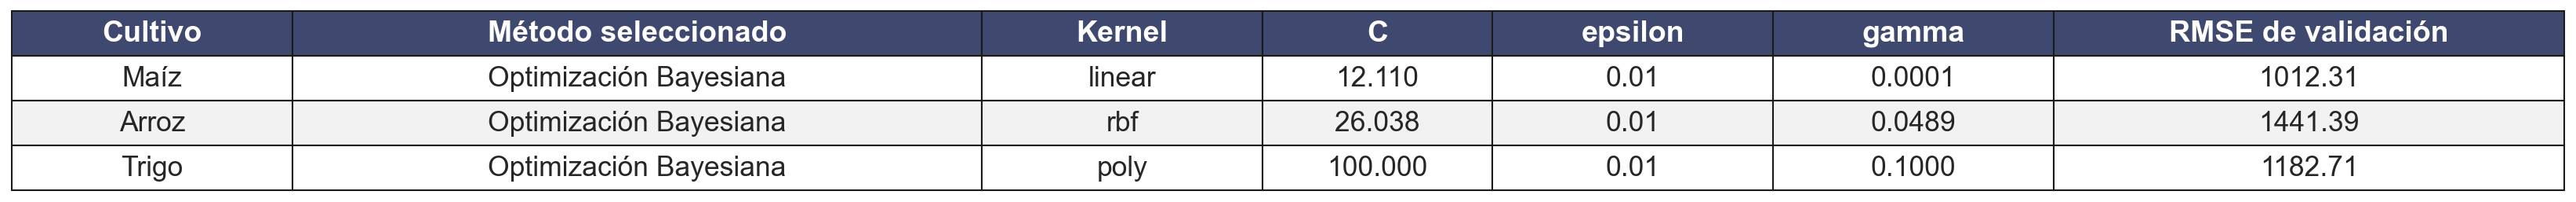

In [38]:
tabla_svr_final = crear_tabla_svr_final()

In [39]:
def crear_tabla_grupos_variables(
    guardar=True,
    ruta_base="Figuras/tabla_grupos_variables"
):
    """
    Crea, guarda y muestra la tabla de agrupación de variables por familia.
    """

    datos = [
        {
            "Grupo": "Vegetación",
            "Variables asociadas": "NDVI, FPAR",
            "Interpretación": "Indicadores relacionados con vigor vegetal y actividad fotosintética."
        },
        {
            "Grupo": "Agua / humedad",
            "Variables asociadas": "RAIN, SM, SM_combined",
            "Interpretación": "Variables vinculadas a precipitación y disponibilidad hídrica del suelo."
        },
        {
            "Grupo": "Temperatura / térmica",
            "Variables asociadas": "TEMP, BT4",
            "Interpretación": "Variables relacionadas con temperatura del aire y comportamiento térmico de la superficie."
        },
        {
            "Grupo": "Radiación",
            "Variables asociadas": "rad",
            "Interpretación": "Energía solar disponible para el desarrollo del cultivo."
        },
        {
            "Grupo": "Contexto climático",
            "Variables asociadas": "koppen_class",
            "Interpretación": "Descriptor estático del régimen climático dominante del país."
        },
        {
            "Grupo": "Temporal",
            "Variables asociadas": "year",
            "Interpretación": "Variable que puede capturar tendencias históricas no explicadas directamente por el resto de predictores."
        }
    ]

    df_tabla = pd.DataFrame(datos)

    wrap_config = {
        "Grupo": 24,
        "Variables asociadas": 28,
        "Interpretación": 70
    }

    for col, width in wrap_config.items():
        df_tabla[col] = df_tabla[col].apply(
            lambda x: "\n".join(textwrap.wrap(str(x), width=width))
        )

    fig, ax = plt.subplots(figsize=(20, 8))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_tabla.values,
        colLabels=df_tabla.columns,
        cellLoc="left",
        colLoc="center",
        loc="center",
        colWidths=[0.25, 0.25, 0.50]
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(18)
    tabla.scale(1.05, 1.0)

    n_columnas = len(df_tabla.columns)

    # Cabecera
    for col in range(n_columnas):
        cell = tabla[(0, col)]
        cell.set_facecolor("#3f486f")
        cell.set_text_props(
            weight="bold",
            color="white",
            fontsize=22,
            ha="center",
            va="center"
        )
        cell.set_height(0.14)

    # Filas
    altura_base = 0.075
    altura_minima = 0.13

    for row in range(1, len(df_tabla) + 1):

        max_lineas = max(
            str(df_tabla.iloc[row - 1, col]).count("\n") + 1
            for col in range(n_columnas)
        )

        altura_fila = max(altura_minima, altura_base * max_lineas)

        for col in range(n_columnas):
            cell = tabla[(row, col)]
            cell.set_height(altura_fila)
            cell.set_text_props(va="center")

            if row % 2 == 0:
                cell.set_facecolor("#f2f2f2")
            else:
                cell.set_facecolor("white")


    plt.tight_layout()

    if guardar:
        plt.savefig(f"{ruta_base}.svg", format="svg", bbox_inches="tight")
        plt.savefig(f"{ruta_base}.pdf", format="pdf", bbox_inches="tight")
        plt.savefig(f"{ruta_base}.png", format="png", dpi=300, bbox_inches="tight")

    plt.show()

    return df_tabla

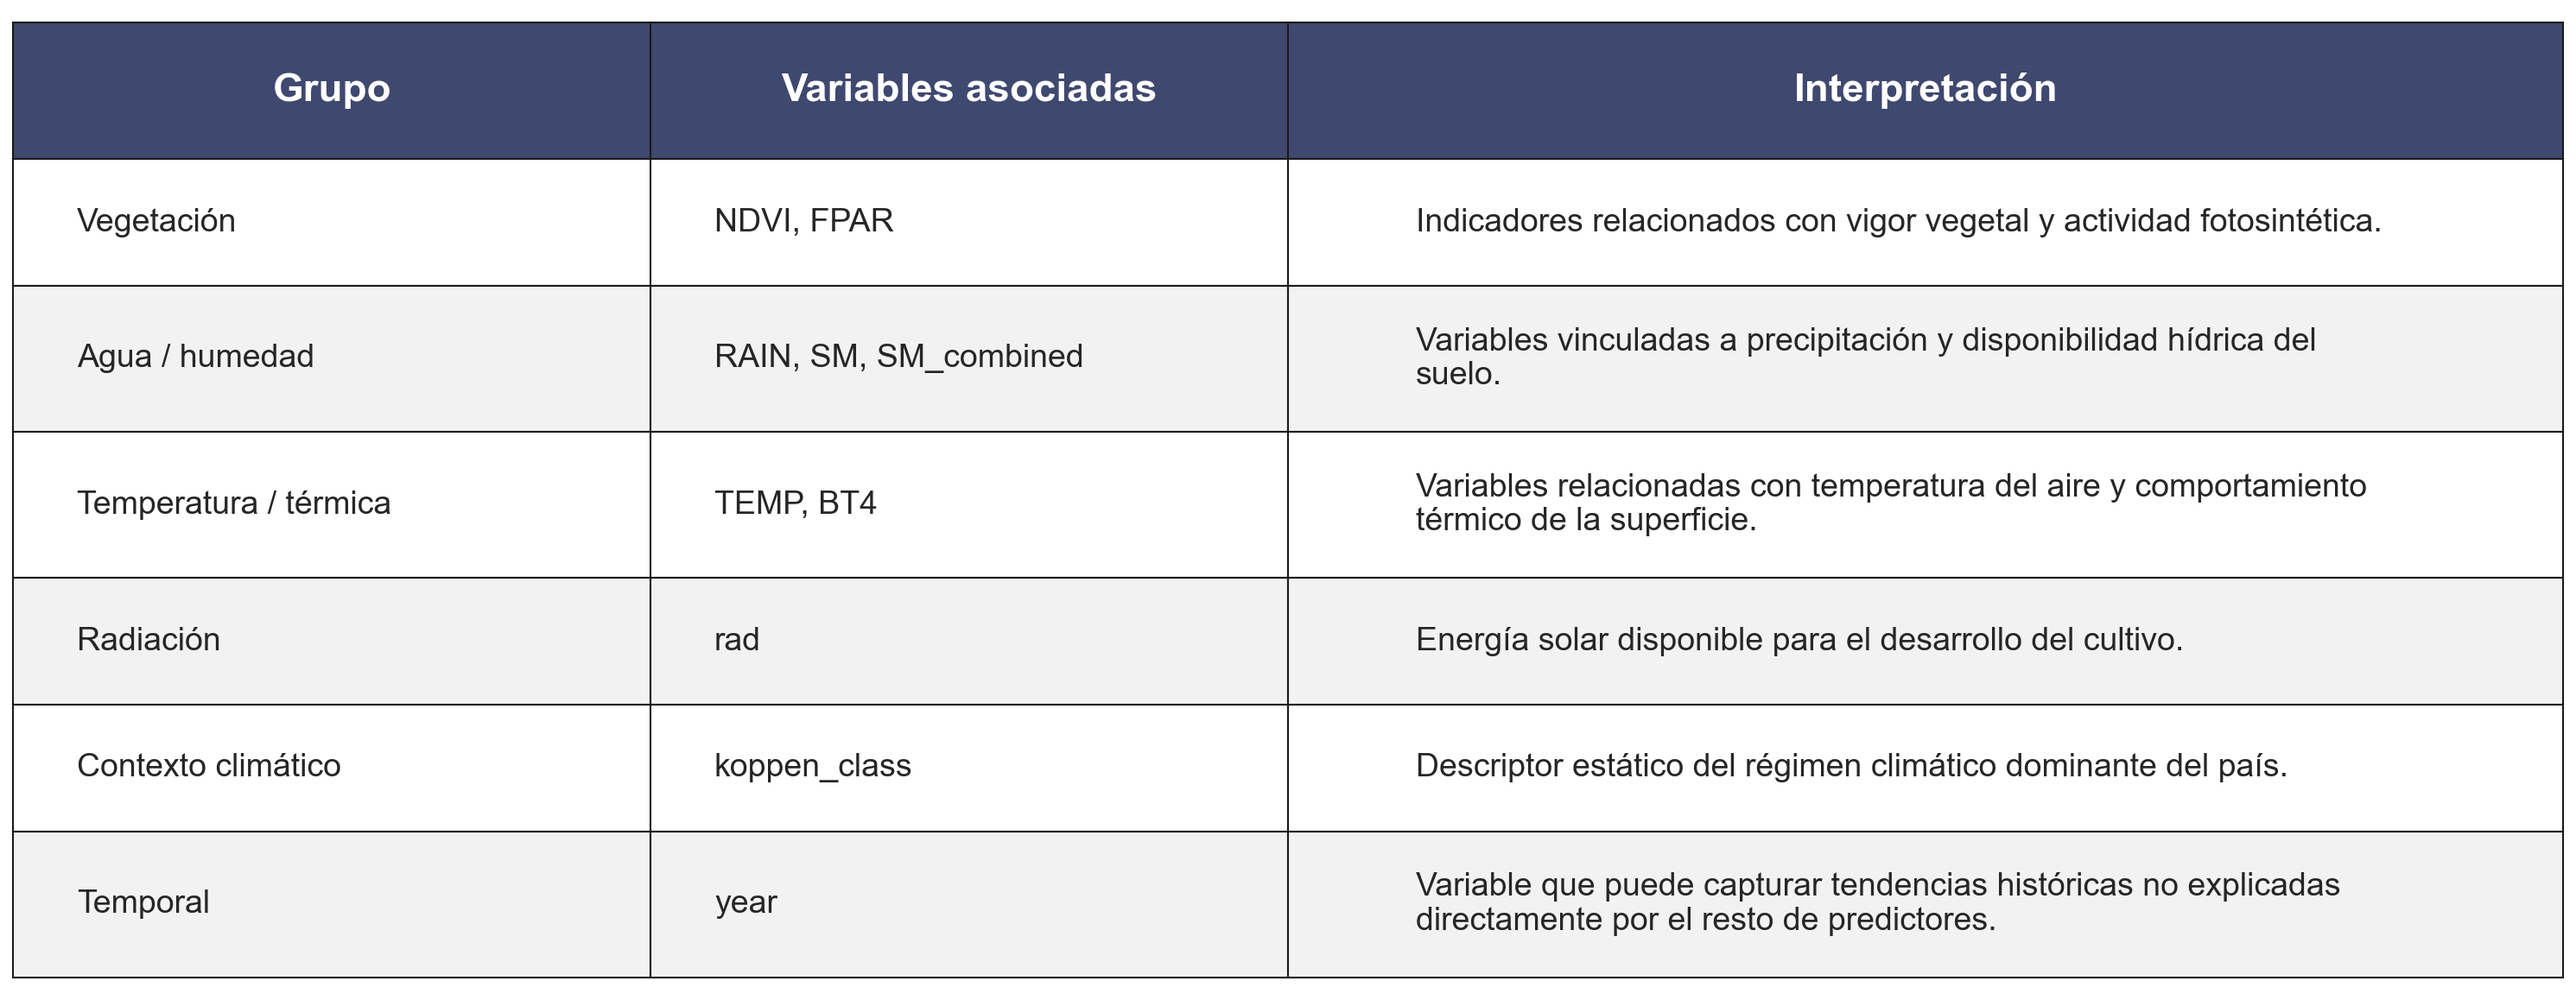

In [40]:
tabla_grupos = crear_tabla_grupos_variables()